In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

# Import addionally libraries
import matplotlib.pyplot as plt
import seaborn as sns

/kaggle/input/datasets/toriqulstu/worlds-real-estate-data147k/world_real_estate_data(147k).csv


In [2]:
# Safe Dataloading
real_estate_data = ('/kaggle/input/datasets/toriqulstu/worlds-real-estate-data147k/world_real_estate_data(147k).csv')

try:
    df = pd.read_csv(real_estate_data)
    print(f'File Loaded successfully')
except FileNotFoundError:
    print(f'File Not Found - check {real_estate_data}')
except Exception as e:
    print(f'Error occured - check {e}')

File Loaded successfully


In [3]:
# Inspection of Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147536 entries, 0 to 147535
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   title                       147536 non-null  object 
 1   country                     147406 non-null  object 
 2   location                    147405 non-null  object 
 3   building_construction_year  64719 non-null   float64
 4   building_total_floors       68224 non-null   float64
 5   apartment_floor             54592 non-null   float64
 6   apartment_rooms             74178 non-null   float64
 7   apartment_bedrooms          36982 non-null   float64
 8   apartment_bathrooms         55973 non-null   float64
 9   apartment_total_area        141796 non-null  object 
 10  apartment_living_area       27712 non-null   object 
 11  price_in_USD                144961 non-null  float64
 12  image                       147536 non-null  object 
 13  url           

In [4]:
# Check columns
print(f'Rows: {df.shape[0]} -- Columns: {df.shape[1]}')

Rows: 147536 -- Columns: 14


In [5]:
# Check metrics of Dataset

df.describe()

,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,price_in_USD
count,64719.000000,68224.000000,54592.000000,74178.000000,36982.000000,55973.000000,1.449610e+05
mean,1996.921754,8.575692,5.791709,2.572097,2.289222,1.364229,4.121722e+05
std,157.527635,8.356781,5.541368,1.319545,18.276913,0.745019,8.420984e+05
min,1.000000,-1.000000,-2.000000,-1.000000,-1.000000,1.000000,0.000000e+00
25%,2004.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.054200e+05
50%,2021.000000,5.000000,4.000000,2.000000,2.000000,1.000000,1.902120e+05
75%,2024.000000,14.000000,8.000000,3.000000,3.000000,2.000000,3.989300e+05
max,2316.000000,124.000000,202.000000,124.000000,2009.000000,43.000000,3.060283e+07


In [6]:
# Inspection of first 5 rows

df.head()

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url
0,2 room apartment 120 m² in Mediterranean Regio...,Turkey,"Mediterranean Region, Turkey",NaN,5.0,1.0,3.0,2.0,2.0,120 m²,110 m²,315209.0,https://realting.com/uploads/bigSlider/ab3/888...,https://realting.com/property-for-sale/turkey/...
1,"4 room villa 500 m² in Kalkan, Turkey",Turkey,"Kalkan, Mediterranean Region, Kas, Turkey",2021.0,2.0,NaN,NaN,NaN,NaN,500 m²,480 m²,1108667.0,https://realting.com/uploads/bigSlider/87b/679...,https://realting.com/property-for-sale/turkey/...
2,"1 room apartment 65 m² in Antalya, Turkey",Turkey,"Mediterranean Region, Antalya, Turkey",NaN,5.0,2.0,2.0,1.0,1.0,65 m²,60 m²,173211.0,https://realting.com/uploads/bigSlider/030/a11...,https://realting.com/property-for-sale/turkey/...
3,"1 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2020.0,15.0,5.0,2.0,1.0,1.0,NaN,40 m²,99900.0,https://realting.com/uploads/bigSlider/e9a/e06...,https://realting.com/property-for-sale/thailan...
4,"2 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2026.0,8.0,3.0,3.0,2.0,1.0,NaN,36 m²,67000.0,https://realting.com/uploads/bigSlider/453/aa2...,https://realting.com/property-for-sale/thailan...


In [7]:
# Check missing values

df.isna().sum()

title                              0
country                          130
location                         131
building_construction_year     82817
building_total_floors          79312
apartment_floor                92944
apartment_rooms                73358
apartment_bedrooms            110554
apartment_bathrooms            91563
apartment_total_area            5740
apartment_living_area         119824
price_in_USD                    2575
image                              0
url                                0
dtype: int64

**Note:** Missing values need to be handled in FE.

In [8]:
# Checking negativ values for 'apartment_floor'
print(df['apartment_floor'].min())
print(df['apartment_floor'].value_counts().sort_index().head())

-2.0
apartment_floor
-2.0       1
-1.0     414
 1.0    9257
 2.0    7994
 3.0    6847
Name: count, dtype: int64


In [9]:
# Checking negativ values for 'apartment_bedrooms'
print(df['apartment_bedrooms'].min())
print(df['apartment_bedrooms'].value_counts().sort_index().head())

-1.0
apartment_bedrooms
-1.0       37
 1.0    11269
 2.0    14433
 3.0     8550
 4.0     1968
Name: count, dtype: int64


### Initial Assessment of Negative Values

Negative values were found in `building_total_floors`, `apartment_floor` and `apartment_bedrooms`.

- `building_total_floors = -1` is likely an invalid value, as a building cannot have a negative number of floors.
- `apartment_floor = -1` could potentially represent a basement or another below-ground floor and should therefore be investigated further before being removed.
- `apartment_bedrooms = -1` occurs only 37 times and may represent missing or unspecified information.

These values will be considered individually during the data-cleaning process rather than being removed automatically.

In [10]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

**Note:** No Duplicates in the dataset

In [11]:
# Check prices by country
display(
    df.groupby('country')['price_in_USD']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

,count,mean,median,min,max
country,,,,,
Italy,3002,1.631403e+06,792638.0,23754.0,30602832.0
UAE,2674,1.308989e+06,514822.5,60500.0,29131024.0
United States,414,1.232923e+06,672637.0,108364.0,16843557.0
Portugal,2103,9.649344e+05,675032.0,136620.0,7929687.0
Spain,14937,7.388327e+05,384429.0,32696.0,21738563.0
Croatia,2025,7.147181e+05,413033.0,70647.0,5807513.0
Greece,12341,6.550324e+05,404395.0,30434.0,10981710.0
Australia,1,5.590000e+05,559000.0,559000.0,559000.0
Latvia,2294,5.443125e+05,375574.5,34782.0,6557750.0


### Prices by Country

The analysis shows noticeable differences in both the number of properties and their prices across countries.

- **Italy** has a relatively low number of properties compared to countries such as Spain, Turkey and Hungary, but shows the highest average (`mean`) and median property prices in the dataset.
- **Spain, Turkey and Hungary** have significantly higher numbers of properties, while their average and median prices are considerably lower than those of Italy.
- The large difference between the mean and median in several countries suggests that high-priced properties may be influencing the average price.
- **Hungary** has a minimum price of `$0`, which appears unusual and should be investigated further during the data-cleaning process.
- Countries with very few properties, such as Australia with only one observation, should not be used for meaningful comparisons.

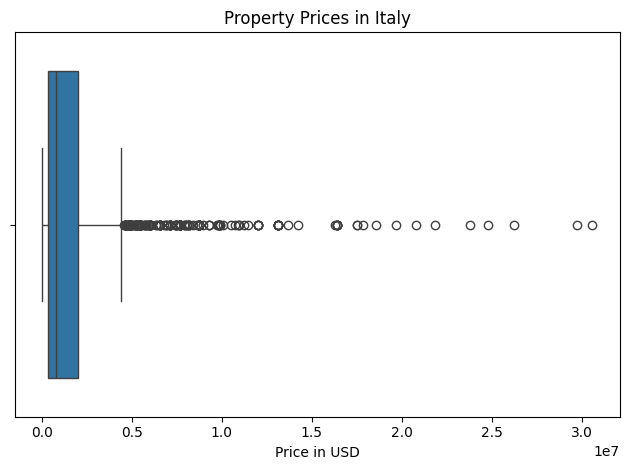

In [12]:
# Check Price for Italy via Boxplot

italy = df[df['country'] == 'Italy']

sns.boxplot(data=italy, x='price_in_USD')

plt.title('Property Prices in Italy')
plt.xlabel('Price in USD')
plt.tight_layout()
plt.show()

### Price Distribution in Italy

The boxplot shows a strongly right-skewed distribution of property prices in Italy. Most properties are concentrated in the lower price range, while numerous high-value outliers extend to more than $30 million.

These extreme values likely pull the mean price of approximately $1.63 million upward. With a median of approximately $793,000, the median appears to be a more representative measure of the typical property price.

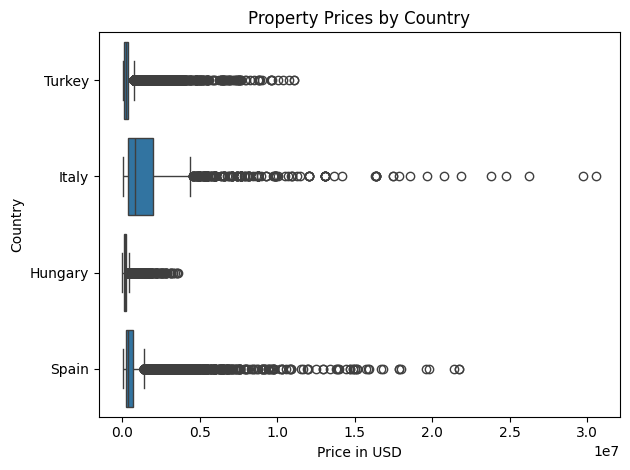

In [13]:
# Check for Price Distribution for Spain, Turkey and Hungary

countries = ['Spain', 'Turkey', 'Hungary', 'Italy']

sns.boxplot(
    data=df[df['country'].isin(countries)],
    x='price_in_USD',
    y='country'
)

plt.title('Property Prices by Country')
plt.xlabel('Price in USD')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Price Distribution Comparison

The boxplot shows that property prices are strongly right-skewed in Spain, Turkey and Hungary.

- **Spain** shows the widest price range and several high-value outliers, with some properties exceeding $20 million.
- **Turkey** also has numerous high-value outliers, but the overall price distribution is lower than in Spain.
- **Hungary** has the lowest overall price distribution among the three countries and fewer extreme values.

The large number of high-value outliers in all three countries suggests that extreme property prices may influence the mean and make the median a more representative measure of a typical property price.

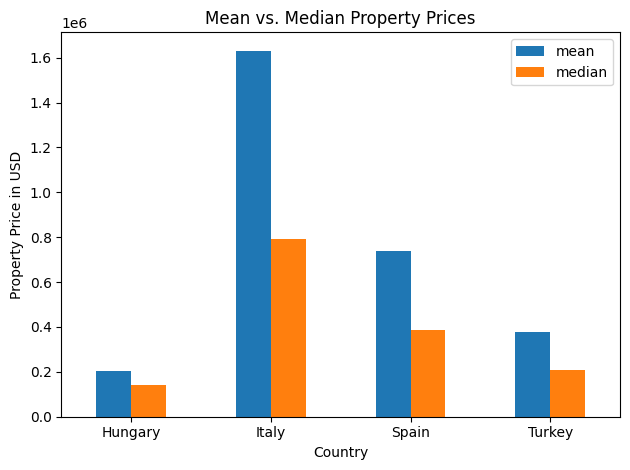

In [14]:
# Price Comparison Mean vs. Median for Spain, Turkey, Hungary and Italy

countries = ['Spain', 'Turkey', 'Hungary', 'Italy']

price_comparison = (
    df[df['country'].isin(countries)]
    .groupby('country')['price_in_USD']
    .agg(['mean', 'median'])
)

price_comparison.plot(kind='bar')

plt.title('Mean vs. Median Property Prices')
plt.xlabel('Country')
plt.ylabel('Property Price in USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Mean vs. Median Price Comparison

The comparison shows that the mean property price is higher than the median in all four countries.

- **Italy** has the highest mean and median prices, with a particularly large difference between the two values.
- **Spain** also shows a noticeable difference between mean and median.
- **Turkey** and **Hungary** have considerably lower price levels, but their means are still higher than their medians.
- The higher mean values are consistent with the right-skewed distributions observed in the boxplots, indicating that high-priced properties are pulling the average price upward.

Overall, the median appears to provide a more representative measure of the typical property price than the mean when extreme values are present.

In [15]:
# Inspect apartment_total_area
print(df['apartment_total_area'].value_counts().head(20))
print('='*30)
print(df['apartment_total_area'].nunique())
print('='*30)
print(df['apartment_total_area'].head(20))

apartment_total_area
100 m²    2468
60 m²     2425
50 m²     2261
55 m²     2112
120 m²    2106
70 m²     2044
90 m²     1944
110 m²    1907
65 m²     1859
75 m²     1837
80 m²     1813
150 m²    1593
40 m²     1510
200 m²    1480
45 m²     1351
38 m²     1344
52 m²     1320
62 m²     1300
53 m²     1290
56 m²     1283
Name: count, dtype: int64
1492
0     120 m²
1     500 m²
2      65 m²
3        NaN
4        NaN
5      28 m²
6     245 m²
7        NaN
8      74 m²
9      50 m²
10     96 m²
11     48 m²
12    312 m²
13    555 m²
14     38 m²
15     54 m²
16     36 m²
17    150 m²
18     25 m²
19     25 m²
Name: apartment_total_area, dtype: object


In [16]:
df[
    df['apartment_total_area'].notna() &
    ~df['apartment_total_area']
    .astype('string')
    .str.match(r'^\d+(\.\d+)?\s*m²$', na=False)
]['apartment_total_area'].unique()

array(['1 000 m²', '130 318 m²', '4 000 m²', '10 069 m²', '1 200 m²',
       '65 000 m²', '12 313 m²', '1 424 m²', '43 492 m²', '1 128 m²',
       '8 460 m²', '13 200 m²', '13 800 m²', '400 000 m²', '2 222 m²',
       '15 273 m²', '1 359 m²', '6 400 m²', '17 500 m²', '515 449 m²',
       '87 000 m²', '10 198 m²', '28 002 m²', '16 197 m²', '45 000 m²',
       '76 000 m²', '142 000 m²', '36 405 773 m²', '183 000 m²',
       '1 056 m²', '19 768 m²', '8 815 m²', '1 052 m²', '425 083 m²',
       '160 000 m²', '1 127 m²', '11 945 m²', '1 350 m²', '2 630 m²',
       '1 150 m²', '1 420 m²', '1 050 m²', '1 406 m²', '1 577 m²',
       '1 121 m²', '2 435 m²', '196 000 m²', '1 030 m²', '1 047 m²',
       '2 500 m²', '1 043 m²', '3 000 m²', '1 300 m²', '1 320 m²',
       '2 700 m²', '1 538 m²', '1 010 m²', '2 200 m²', '1 054 m²',
       '1 220 m²', '1 324 m²', '2 000 m²', '1 356 m²', '1 526 m²',
       '1 270 m²', '9 160 m²', '2 850 m²', '1 001 m²', '1 042 m²',
       '1 037 m²', '1 130 m²', '5 100

In [17]:
# Create new column with only total area numbers without space 
df['apartment_total_area_clean'] = (
    df['apartment_total_area']
    .str.replace(' m²', '', regex=False)
    .str.replace(' ', '', regex=False)
    .astype(float)
)

In [18]:
# Check the new column
df[['apartment_total_area', 'apartment_total_area_clean']].head(20)

,apartment_total_area,apartment_total_area_clean
0,120 m²,120.0
1,500 m²,500.0
2,65 m²,65.0
3,NaN,NaN
4,NaN,NaN
5,28 m²,28.0
6,245 m²,245.0
7,NaN,NaN
8,74 m²,74.0
9,50 m²,50.0


In [19]:
df['apartment_total_area_clean'].describe()

count    1.417960e+05
mean     5.044077e+02
std      9.695024e+04
min      1.000000e+00
25%      5.700000e+01
50%      8.900000e+01
75%      1.500000e+02
max      3.640577e+07
Name: apartment_total_area_clean, dtype: float64

In [20]:
# Inspect apartment_living_area
print(df['apartment_living_area'].value_counts().head(20))
print('='*30)
print(df['apartment_living_area'].nunique())
print('='*30)
print(df['apartment_living_area'].head(20))

apartment_living_area
30 m²    888
17 m²    698
28 m²    639
32 m²    625
29 m²    612
31 m²    554
40 m²    540
33 m²    539
45 m²    513
50 m²    506
34 m²    456
35 m²    453
43 m²    440
44 m²    435
18 m²    432
42 m²    428
36 m²    409
41 m²    387
16 m²    373
38 m²    370
Name: count, dtype: int64
641
0     110 m²
1     480 m²
2      60 m²
3      40 m²
4      36 m²
5        NaN
6     245 m²
7      25 m²
8        NaN
9        NaN
10     86 m²
11       NaN
12       NaN
13       NaN
14     38 m²
15     54 m²
16       NaN
17    135 m²
18       NaN
19       NaN
Name: apartment_living_area, dtype: object


In [21]:
df[
    df['apartment_living_area'].notna() &
    ~df['apartment_living_area']
    .astype('string')
    .str.match(r'^\d+(\.\d+)?\s*m²$', na=False)
]['apartment_living_area'].unique()

array(['13 800 m²', '49 000 m²', '135 000 m²', '47 000 m²', '1 312 m²',
       '35 672 m²', '4 152 m²', '62 692 m²', '42 582 m²', '41 122 m²',
       '41 612 m²', '4 042 m²', '42 482 m²', '54 282 m²', '46 552 m²',
       '60 382 m²', '5 382 m²', '4 972 m²', '89 912 m²', '5 412 m²',
       '74 342 m²', '1 082 m²', '6 242 m²', '6 262 m²', '8 122 m²',
       '6 272 m²', '128 532 m²', '6 912 m²', '67 000 m²', '7 662 000 m²',
       '5 000 m²', '2 400 m²', '1 550 m²', '1 030 m²', '2 500 m²',
       '56 000 m²', '28 773 m²', '14 500 m²', '1 857 m²', '6 336 m²',
       '4 800 m²', '41 462 m²', '41 492 m²', '47 792 m²', '41 392 m²',
       '41 332 m²', '62 542 m²', '81 000 m²', '61 582 m²', '41 922 m²',
       '62 682 m²', '1 450 m²', '1 002 m²', '1 150 m²', '1 033 m²',
       '1 444 m²', '2 140 m²', '2 470 m²', '2 099 m²', '1 621 m²',
       '1 269 m²', '1 225 m²', '1 780 m²', '1 026 m²', '1 800 m²',
       '7 000 m²', '95 000 m²', '1 100 m²', '1 400 m²', '1 230 m²',
       '1 156 m²', '10 56

In [22]:
# Create new column with only total area numbers without space 
df['apartment_living_area_clean'] = (
    df['apartment_living_area']
    .str.replace(' m²', '', regex=False)
    .str.replace(' ', '', regex=False)
    .astype(float)
)

In [23]:
# Check the new column
df[['apartment_total_area', 'apartment_total_area_clean']].head(20)

,apartment_total_area,apartment_total_area_clean
0,120 m²,120.0
1,500 m²,500.0
2,65 m²,65.0
3,NaN,NaN
4,NaN,NaN
5,28 m²,28.0
6,245 m²,245.0
7,NaN,NaN
8,74 m²,74.0
9,50 m²,50.0


In [24]:
df['apartment_living_area_clean'].describe()

count    2.771200e+04
mean     7.435988e+02
std      6.514935e+04
min      1.000000e+00
25%      3.100000e+01
50%      4.600000e+01
75%      8.800000e+01
max      7.662000e+06
Name: apartment_living_area_clean, dtype: float64

In [25]:
# Check if both new columns are numeric
df[['apartment_total_area_clean', 'apartment_living_area_clean']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147536 entries, 0 to 147535
Data columns (total 2 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   apartment_total_area_clean   141796 non-null  float64
 1   apartment_living_area_clean  27712 non-null   float64
dtypes: float64(2)
memory usage: 2.3 MB


In [26]:
# Quick check of largest apartment_total_area_clean

df.nlargest(
    10, 
    'apartment_total_area_clean'
)[
    ['country', 
    'location',
    'apartment_total_area_clean', 
    'apartment_living_area_clean', 
    'price_in_USD']
]

,country,location,apartment_total_area_clean,apartment_living_area_clean,price_in_USD
18941,Montenegro,"Bar, Bar Municipality, Montenegro",36405773.0,NaN,78259.0
136130,Italy,"Poggibonsi, Tuscany, Siena, Italy",1250000.0,NaN,16394374.0
110908,Montenegro,"Dobrota, Kotor Municipality, Montenegro",1200000.0,NaN,1304314.0
120333,Poland,"Masovian Voivodeship, Warsaw, Poland",1148000.0,NaN,257272.0
136552,Italy,"Case di Coccia, Marche, Ascoli Piceno, Italy",850000.0,NaN,1912677.0
108540,Spain,"Helechosa de los Montes, Extremadura, Badajoz,...",747579.0,NaN,279341.0
10899,Turkey,"Fatih, Marmara Region, Turkey",515449.0,77.0,546990.0
49669,Hungary,"Nagykanizsa, Transdanubia, Nagykanizsai jaras,...",473884.0,NaN,98408.0
21341,Montenegro,"Bar, Bar Municipality, Montenegro",425083.0,NaN,91302.0
8420,Turkey,"Sariyer, Marmara Region, Cumhuriyet Mahallesi,...",400000.0,NaN,2500000.0


In [27]:
# Quick check of largest apartment_living_area_clean

df.nlargest(
    10, 
    'apartment_living_area_clean'
)[
    ['country', 
    'location',
    'apartment_total_area_clean', 
    'apartment_living_area_clean', 
    'price_in_USD']
]

,country,location,apartment_total_area_clean,apartment_living_area_clean,price_in_USD
85295,Turkey,"Marmara Region, Turkey",140.0,7662000.0,638000.0
86249,Turkey,"Marmara Region, Turkey",274.0,7662000.0,1200000.0
138269,Portugal,"Centro, Santa Maria Maior, West, Portugal",NaN,220000.0,1038310.0
54394,Hungary,"Heviz, Transdanubia, Keszthelyi jaras, Zala, H...",135000.0,135000.0,318015.0
84612,Austria,"Vienna, Austria",128532.0,128532.0,1084754.0
126024,Greece,"Kriopigi, Macedonia and Thrace, Municipality o...",NaN,95000.0,196950.0
84545,Austria,"Vienna, Austria",89912.0,89912.0,726155.0
94595,Belarus,"Vitsebsk Region, Sakaliscanski sielski Saviet,...",113.0,81000.0,13900.0
84552,Austria,"Vienna, Austria",74342.0,74342.0,553899.0
85110,Turkey,"Marmara Region, Turkey",132.0,67000.0,352000.0


In [28]:
df[df['apartment_total_area_clean'] > 5000][
    ['country',
    'location', 
    'apartment_total_area_clean', 
    'apartment_living_area_clean', 
    'price_in_USD'
    ]
].head(20)

,country,location,apartment_total_area_clean,apartment_living_area_clean,price_in_USD
1363,Turkey,"Marmara Region, Izmit, Turkey",130318.0,NaN,182000.0
2452,Turkey,"Marmara Region, Fatih Sultan Mehmet Mahallesi,...",10069.0,NaN,149801.0
2760,Turkey,"Mediterranean Region, Sekerhane Mahallesi, Ala...",65000.0,NaN,46609.0
3850,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",12313.0,NaN,782588.0
4309,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",43492.0,NaN,1869311.0
5816,Turkey,"Mediterranean Region, Sekerhane Mahallesi, Ala...",8460.0,NaN,336215.0
5860,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",13200.0,NaN,329339.0
6491,Turkey,"Kargicak, Mediterranean Region, Alanya, Turkey",13800.0,13800.0,NaN
8420,Turkey,"Sariyer, Marmara Region, Cumhuriyet Mahallesi,...",400000.0,NaN,2500000.0
9592,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",15273.0,NaN,581507.0


In [29]:
print((df['apartment_total_area_clean'] > 1000).sum())
print((df['apartment_total_area_clean'] > 5000).sum())

935
254


In [30]:
# Check how much entries of living area are bigger then total area
print((df['apartment_living_area_clean'] > df['apartment_total_area_clean']).sum())

77


In [31]:
# Inspection of the 77 entries
df[df['apartment_living_area_clean'] > df['apartment_total_area_clean']][
    [
        'country', 
        'location', 
        'apartment_total_area_clean', 
        'apartment_living_area_clean', 
        'price_in_USD'
    ]
].head(20)

,country,location,apartment_total_area_clean,apartment_living_area_clean,price_in_USD
1188,Turkey,"Mediterranean Region, Antalya, Turkey",100.0,120.0,226081.0
1356,Turkey,"Koyunlar, Mediterranean Region, Antalya, Turkey",100.0,145.0,149996.0
1556,Turkey,"Avsallar, Mediterranean Region, Alanya, Turkey",109.0,117.0,153257.0
4110,Turkey,"Marmara Region, Turkey",128.0,158.0,744546.0
5809,Turkey,"Marmara Region, Turkey",61.0,82.0,371729.0
8907,Turkey,"Karakocali, Mediterranean Region, Alanya, Turkey",170.0,205.0,586941.0
9593,Turkey,"Marmara Region, Piri Pasa Mahallesi, Turkey",125.0,130.0,373903.0
10173,Turkey,"Marmara Region, Turkey",120.0,145.0,550000.0
10483,Turkey,"Marmara Region, Besevler Mahallesi, Niluefer, ...",430.0,500.0,566290.0
11174,Turkey,"Black Sea Region, Turkey",187.0,256.0,NaN


In [32]:
# Check how much entries of apartment total area are smaller then 500
print(
    df[df['apartment_total_area_clean'] <= 500][
        'apartment_total_area_clean'
    ]
.describe())

count    137940.000000
mean        116.507387
std          90.169010
min           1.000000
25%          56.000000
50%          86.000000
75%         145.000000
max         500.000000
Name: apartment_total_area_clean, dtype: float64


### Assessment of Apartment Area Values

The cleaned area variables were examined for implausible and inconsistent values.

- `apartment_total_area_clean` contains **141,796** non-null values. The median is **86 m²**, while 75% of the observations are below **145 m²**.
- The mean of **504 m²** is substantially higher than the median, indicating a strong influence of extreme values.
- The maximum value of **36,405,773 m²** is clearly implausible for a typical apartment and indicates severe outliers in the dataset.
- **935 observations** have a total area above 1,000 m², and **254 observations** exceed 5,000 m².
- A further consistency check identified **77 observations** where `apartment_living_area_clean` is larger than `apartment_total_area_clean`. These values were considered inconsistent and require careful handling.
- When restricting the total area to values of **500 m² or less**, the mean decreases to **116.5 m²** and the median remains at **86 m²**, resulting in a much more plausible distribution.

For the subsequent analysis of the relationship between apartment area and price, values above **500 m²** will therefore be treated as extreme values and excluded from the analysis variable. The original cleaned area column will be retained to preserve the original information.

In [33]:
# Exclude the outliers from inspection above and only use apartment total area clean with smaller size of 500
df['apartment_total_area_analysis'] = df['apartment_total_area_clean'].where(
    df['apartment_total_area_clean'] <= 500
)

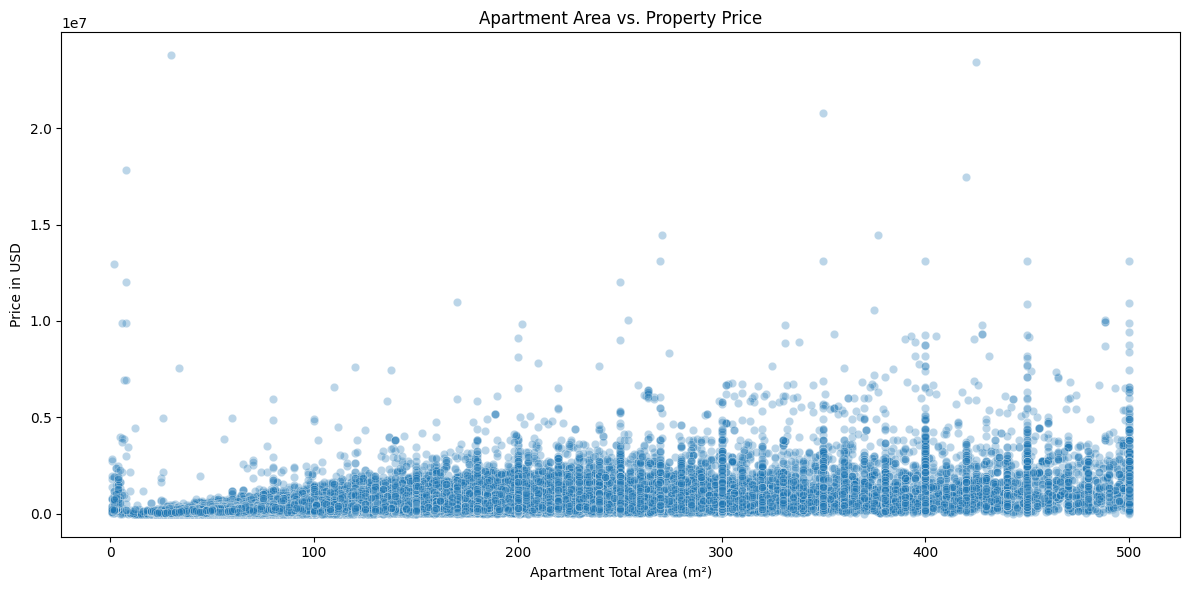

In [34]:
# Check for context between size of the apartment and price
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='apartment_total_area_analysis', 
    y='price_in_USD', 
    alpha=0.3
)

plt.title('Apartment Area vs. Property Price')
plt.xlabel('Apartment Total Area (m²)')
plt.ylabel('Price in USD')
plt.tight_layout()
plt.show()

### Relationship Between Apartment Area and Price

The scatterplot indicates a generally positive relationship between apartment area and property price. Larger apartments tend to have higher prices, but the data points show considerable variation.

Several high-priced properties are visible as outliers, which makes the relationship less clear. Therefore, correlation measures will be used next to quantify the relationship between apartment area and price.

In [35]:
# Correlation check pearson method

correlation_pearson = df[
    ['apartment_total_area_analysis', 'price_in_USD']
].corr(method='pearson')

correlation_pearson

,apartment_total_area_analysis,price_in_USD
apartment_total_area_analysis,1.000000,0.564882
price_in_USD,0.564882,1.000000


In [36]:
# Correlation check spearman method

correlation_spearman = df[
    ['apartment_total_area_analysis', 'price_in_USD']
].corr(method='spearman')

correlation_spearman

,apartment_total_area_analysis,price_in_USD
apartment_total_area_analysis,1.000000,0.701062
price_in_USD,0.701062,1.000000


### Correlation Between Apartment Area and Price

The Pearson correlation coefficient is **0.565**, indicating a moderate positive linear relationship between apartment area and property price.

The Spearman correlation coefficient is **0.701**, indicating a stronger positive monotonic relationship. This suggests that larger apartments generally tend to have higher prices, although the relationship is not strictly linear.

The higher Spearman correlation compared to Pearson indicates that the general ranking between apartment size and price is stronger than their linear relationship. This is consistent with the scatterplot, which shows considerable variation in prices for apartments of similar size.

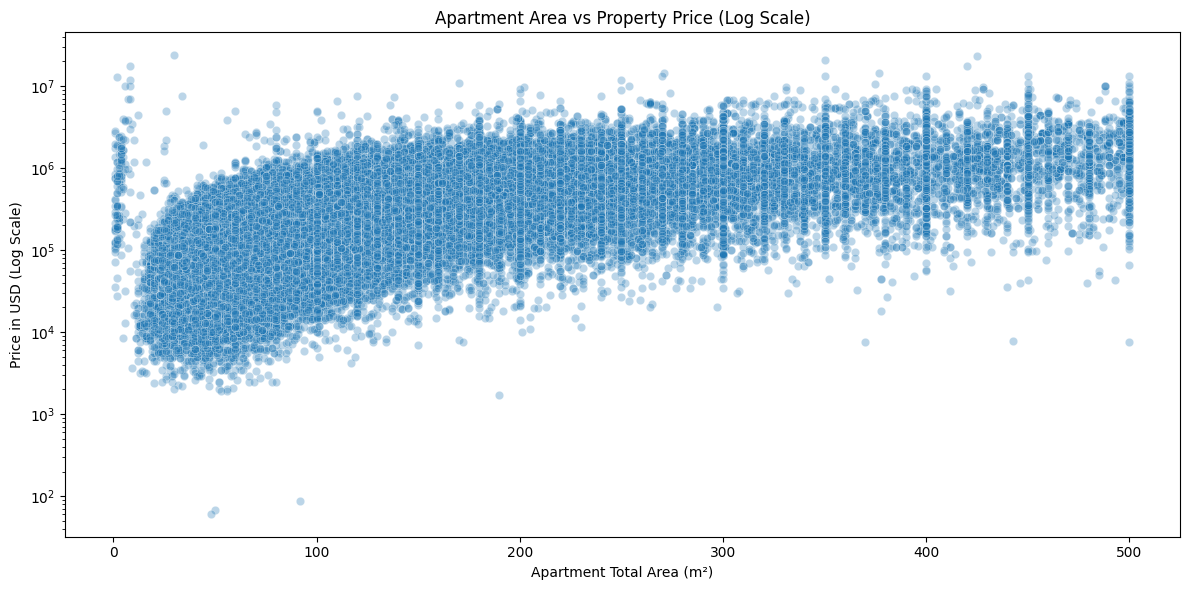

In [37]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df, 
    x='apartment_total_area_analysis',
    y='price_in_USD', 
    alpha=0.3
)

plt.yscale('log')

plt.title('Apartment Area vs Property Price (Log Scale)')
plt.xlabel('Apartment Total Area (m²)')
plt.ylabel('Price in USD (Log Scale)')

plt.tight_layout()
plt.show()

### Apartment Area vs. Property Price – Logarithmic Scale

The logarithmic scale makes the relationship between apartment area and property price easier to interpret, as property prices cover a very wide range.

The plot shows a clear positive trend: larger apartments generally tend to have higher prices. However, there is considerable variation in prices for apartments with similar areas, indicating that apartment size alone does not explain the property price.

The logarithmic scale also makes the distribution of the majority of observations more visible while reducing the visual influence of extreme high-priced properties.

In [38]:
# Analize price per sqm
df['price_per_sqm'] = (
    df['price_in_USD'] / 
    df['apartment_total_area_analysis']
)

In [39]:
# Check metrics of price per sqm
df['price_per_sqm'].describe()

count    1.365670e+05
mean     3.183983e+03
std      2.643690e+04
min      0.000000e+00
25%      1.378100e+03
50%      2.309586e+03
75%      3.349288e+03
max      6.481397e+06
Name: price_per_sqm, dtype: float64

In [40]:
# Inspection of price per sqm which are 0, and greater then 1000 and 5000
print((df['price_per_sqm'] == 0).sum())
print((df['price_per_sqm'] > 1000).sum())
print((df['price_per_sqm'] > 5000).sum())

11
117770
13493


In [41]:
# Check for the 10 largest price per sqm
df.nlargest(10, 'price_per_sqm')[
    [
        'country', 
        'location', 
        'apartment_total_area_analysis', 
        'apartment_living_area',
        'price_in_USD',
        'price_per_sqm'
    ]
]

,country,location,apartment_total_area_analysis,apartment_living_area,price_in_USD,price_per_sqm
98012,Spain,"Andalusia, Marbella, Malaga, Spain",2.0,NaN,12962794.0,6.481397e+06
111422,Montenegro,"Kolašin Municipality, Montenegro",1.0,NaN,2821322.0,2.821322e+06
111137,Montenegro,"Budva, Bar, Bar Municipality, Montenegro",1.0,NaN,2717320.0,2.717320e+06
97989,Spain,"Andalusia, Malaga, Spain",8.0,NaN,17834355.0,2.229294e+06
111670,Montenegro,"Kolašin Municipality, Montenegro",1.0,NaN,1971453.0,1.971453e+06
102158,Spain,"la Bisbal d Emporda, Catalonia, Lower Empordà,...",1.0,NaN,1781220.0,1.781220e+06
136029,Italy,"Positano, Campania, Salerno, Italy",6.0,NaN,9907975.0,1.651329e+06
97909,Spain,"Andalusia, Marbella, Malaga, Spain",8.0,NaN,12011856.0,1.501482e+06
36381,Hungary,"Koroeshegy, Transdanubia, Siofoki jaras, Somog...",1.0,NaN,1368793.0,1.368793e+06
136026,Italy,"Positano, Campania, Salerno, Italy",8.0,NaN,9907975.0,1.238497e+06


### Price per Square Meter

The calculated `price_per_sqm` has a median of approximately **$2,310/m²**, while the mean is higher at approximately **$3,184/m²**.

The maximum value of approximately **$6.48 million/m²** indicates extreme outliers. These values are mainly caused by properties with very small recorded areas combined with high property prices.

Therefore, the extreme `price_per_sqm` values should be investigated further before using this variable for additional analysis.# Check for how much entries does have a smaller total area then 10
print(
    (
        df['apartment_total_area_analysis'] <= 10
    ).sum()
)

In [42]:
# Check for how much entries does have a smaller total area then 10
print(
    (
        df['apartment_total_area_analysis'] <= 10
    ).sum()
)

152


In [43]:
# Check the first 20 entries 
df[df['apartment_total_area_analysis'] <= 10][
        [
            'country', 
            'location', 
            'apartment_total_area_analysis', 
            'apartment_living_area',
            'price_in_USD',
            'price_per_sqm'
        ]
    ].head(20)

,country,location,apartment_total_area_analysis,apartment_living_area,price_in_USD,price_per_sqm
18738,Montenegro,"Kolašin Municipality, Montenegro",1.0,NaN,111788.0,1.117880e+05
19577,Montenegro,"Kolašin Municipality, Montenegro",1.0,NaN,340688.0,3.406880e+05
22208,Montenegro,"Kolašin Municipality, Montenegro",1.0,NaN,127332.0,1.273320e+05
22313,Montenegro,"Kolašin Municipality, Montenegro",1.0,NaN,125096.0,1.250960e+05
23478,Montenegro,"Kolašin Municipality, Montenegro",1.0,NaN,178861.0,1.788610e+05
24509,Montenegro,"Kolašin Municipality, Montenegro",1.0,NaN,174922.0,1.749220e+05
27314,Montenegro,"Kolašin Municipality, Montenegro",1.0,NaN,425860.0,4.258600e+05
33047,Hungary,"Fueloepszallas, Great Plain and North, Kiskoro...",4.0,NaN,88122.0,2.203050e+04
36381,Hungary,"Koroeshegy, Transdanubia, Siofoki jaras, Somog...",1.0,NaN,1368793.0,1.368793e+06
49806,Hungary,"Central Hungary, Budapest, Komarom-Esztergom, ...",8.0,NaN,55607.0,6.950875e+03


In [44]:
# Check entries where price_per_sqm is 0
print(
    (df['price_per_sqm'] == 0).sum()
)

11


In [45]:
for limits in [5, 10, 15, 20, 25, 30]:
    count = (df['apartment_total_area_analysis'] < limits).sum()
    print(f'{limits} m²: {count} entries')

5 m²: 112 entries
10 m²: 147 entries
15 m²: 211 entries
20 m²: 436 entries
25 m²: 3127 entries
30 m²: 4907 entries


In [46]:
# Create new column 
df['apartment_total_area_sqm_analysis'] = df[
    'apartment_total_area_analysis'
].where(
    df['apartment_total_area_analysis'] >= 20
)

In [47]:
# Calculate new price per sqm
df['price_per_sqm_analysis'] = (
    df['price_in_USD'] / df['apartment_total_area_sqm_analysis']
)

In [48]:
# Check metrics of sqm analysis
df['price_per_sqm_analysis'].describe()

count    136132.000000
mean       2744.250482
std        3236.736847
min           0.000000
25%        1377.960769
50%        2307.159457
75%        3342.843339
max      792637.966667
Name: price_per_sqm_analysis, dtype: float64

In [49]:
# Check the entries with min 0 
df[df['price_per_sqm_analysis'] == 0][
    [
        'country', 
        'location', 
        'apartment_total_area_sqm_analysis', 
        'price_in_USD',
        'price_per_sqm_analysis'
    ]
]

,country,location,apartment_total_area_sqm_analysis,price_in_USD,price_per_sqm_analysis
144761,Hungary,"Pusztavacs, Central Hungary, Dabasi jaras, Pes...",74.0,0.0,0.0
144776,Hungary,"Pusztavacs, Central Hungary, Dabasi jaras, Pes...",110.0,0.0,0.0
144777,Hungary,"Pusztavacs, Central Hungary, Dabasi jaras, Pes...",94.0,0.0,0.0
144778,Hungary,"Pusztavacs, Central Hungary, Dabasi jaras, Pes...",129.0,0.0,0.0
144779,Hungary,"Pusztavacs, Central Hungary, Dabasi jaras, Pes...",85.0,0.0,0.0
144780,Hungary,"Pusztavacs, Central Hungary, Dabasi jaras, Pes...",96.0,0.0,0.0
144781,Hungary,"Pusztavacs, Central Hungary, Dabasi jaras, Pes...",104.0,0.0,0.0
144788,Hungary,"Kistarcsa, Central Hungary, Gödöllő Regional U...",108.0,0.0,0.0
144789,Hungary,"Pusztavacs, Central Hungary, Dabasi jaras, Pes...",111.0,0.0,0.0
144790,Hungary,"Pusztavacs, Central Hungary, Dabasi jaras, Pes...",118.0,0.0,0.0


In [50]:
# Check the 10 largest sqm analysis entries
df.nlargest(10, 'price_per_sqm_analysis')[
    [
        'country', 
        'location', 
        'apartment_total_area_sqm_analysis', 
        'price_in_USD',
        'price_per_sqm_analysis'
    ]
]

,country,location,apartment_total_area_sqm_analysis,price_in_USD,price_per_sqm_analysis
136165,Italy,"Lazio, Roma Capitale, Italy",30.0,23779139.0,792637.966667
131148,UAE,"Dubai, UAE",34.0,7573929.0,222762.617647
131067,UAE,"Dubai, UAE",26.0,4944008.0,190154.153846
133910,Thailand,"Chon Buri Province, Pattaya, Thailand",26.0,2182800.0,83953.846154
109858,Spain,"Andalusia, Malaga, Spain",60.0,4948648.0,82477.466667
97937,Spain,"Corbera de Llobregat, Catalonia, Baix Llobrega...",80.0,5944785.0,74309.812500
102934,Spain,"Cassa de la Selva, Catalonia, Girones, Spain",25.0,1840926.0,73637.040000
4494,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",56.0,3858595.0,68903.482143
96938,Spain,"Llagostera, Catalonia, Girones, Spain",25.0,1634816.0,65392.640000
131210,UAE,"Dubai, UAE",170.0,11000000.0,64705.882353


In [51]:
# Exclude entries with price_in_USD == 0
df['price_per_sqm_analysis'] = df['price_per_sqm_analysis'].where(df['price_in_USD'] > 0)

In [52]:
# Check metrics again
df['price_per_sqm_analysis'].describe()

count    136121.000000
mean       2744.472246
std        3236.773610
min           0.956522
25%        1378.164179
50%        2307.344262
75%        3343.000000
max      792637.966667
Name: price_per_sqm_analysis, dtype: float64

In [53]:
# Check quantile
df['price_per_sqm_analysis'].quantile(0.99)

np.float64(10869.28270689655)

### Price per Square Meter – Outlier Analysis

After excluding properties with an apartment area below **20 m²** and properties with a price of **$0**, the `price_per_sqm_analysis` variable shows a more realistic distribution.

- The **median** price is approximately **$2,307/m²**, while the **mean** is approximately **$2,744/m²**.
- The standard deviation decreased substantially compared to the initial calculation, indicating that the extreme values caused by very small apartment areas were strongly reduced.
- The maximum value is still approximately **$792,638/m²**, showing that some extreme outliers remain in the dataset.
- The **99th percentile is approximately $10,869/m²**, meaning that 99% of the observations are below this value.
- The remaining extreme values should not automatically be considered incorrect, as some may represent genuine high-value properties.

For further visualizations, the upper 1% of `price_per_sqm_analysis` can therefore be excluded from the displayed range while keeping the original values available for analysis.

In [54]:
# Check the sqm price by country
price_sqm_by_country = (
    df.groupby('country')['price_per_sqm_analysis']
    .agg(['count', 'median', 'mean'])
    .sort_values('median', ascending=False)
)

price_sqm_by_country

,count,median,mean
country,,,
Austria,137,5726.333333,6108.934601
UAE,2342,5466.749493,6852.871138
Portugal,1710,5168.512716,5645.683241
Czech Republic,1342,4676.401919,4517.505453
Australia,1,4658.333333,4658.333333
Italy,2450,4207.291154,5702.499637
Indonesia,99,3673.469388,3721.193676
Poland,1190,3482.303507,3832.271240
Croatia,1738,3260.781101,3588.043013


In [55]:
# Check sqm by country with more then 500 counts
price_sqm_filtered = price_sqm_by_country[
    price_sqm_by_country['count'] >= 500
]

price_sqm_filtered

,count,median,mean
country,,,
UAE,2342,5466.749493,6852.871138
Portugal,1710,5168.512716,5645.683241
Czech Republic,1342,4676.401919,4517.505453
Italy,2450,4207.291154,5702.499637
Poland,1190,3482.303507,3832.271240
Croatia,1738,3260.781101,3588.043013
Spain,13397,3141.544304,3567.824683
Thailand,1763,3054.194175,3357.807688
Latvia,2155,2801.360825,3149.692439


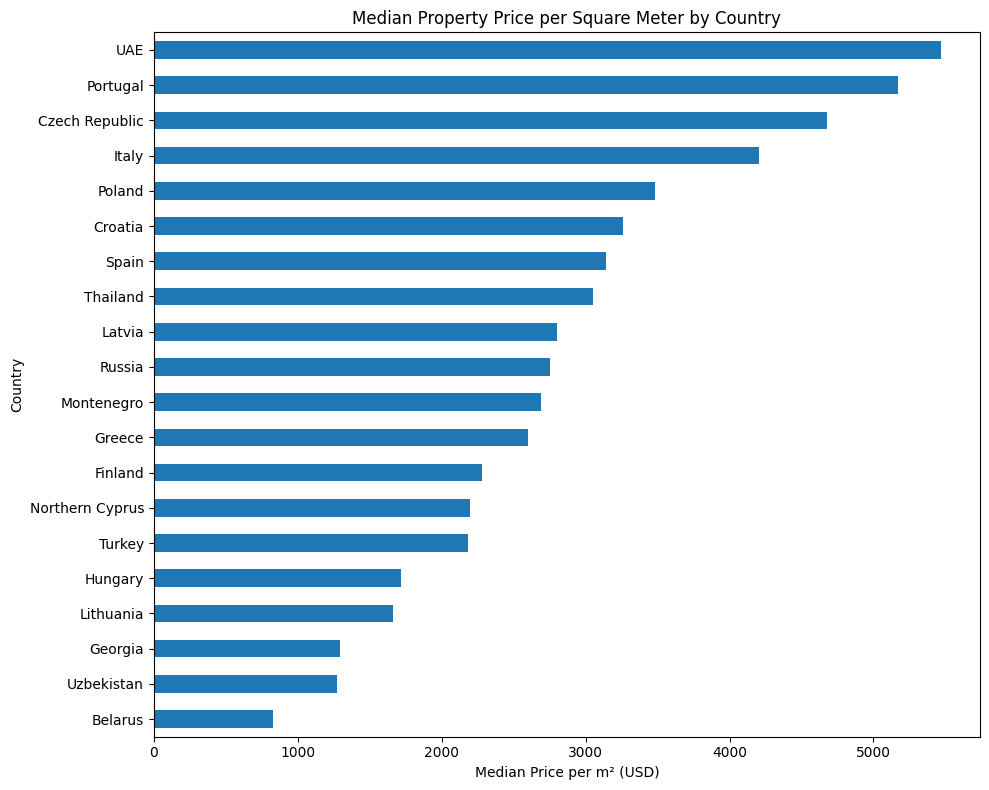

In [56]:
price_sqm_filtered['median'].sort_values().plot(
    kind='barh', 
    figsize=(10,8)
)

plt.title('Median Property Price per Square Meter by Country')
plt.xlabel('Median Price per m² (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Median Property Price per Square Meter by Country

The bar chart compares the median property price per square meter for countries with at least **500 observations**.

- **UAE** has the highest median price at approximately **$5,467/m²**, followed by **Portugal** at approximately **$5,169/m²**.
- **Czech Republic** and **Italy** also show relatively high median prices of approximately **$4,676/m²** and **$4,207/m²** respectively.
- **Spain** has a median price of approximately **$3,142/m²**, despite having one of the largest numbers of observations in the dataset.
- **Turkey** and **Hungary** show considerably lower median prices of approximately **$2,183/m²** and **$1,715/m²**.
- **Belarus** has the lowest median price in this comparison at approximately **$825/m²**.

The results demonstrate substantial differences in property prices per square meter between countries. The median was used instead of the mean because the previous analysis showed a right-skewed distribution with extreme high-value properties.

Countries with fewer than 500 observations were excluded from this comparison to reduce the influence of very small sample sizes.

In [57]:
# Check if the price increase with the number of rooms
df['apartment_rooms'].value_counts().sort_index

<bound method Series.sort_index of apartment_rooms
 2.0      25608
 3.0      23412
 1.0      12208
 4.0       9557
 5.0       2450
 6.0        612
 7.0        139
 8.0         70
-1.0         32
 9.0         25
 10.0        17
 12.0        10
 11.0         7
 13.0         4
 18.0         4
 14.0         3
 16.0         2
 35.0         2
 19.0         1
 30.0         1
 22.0         1
 21.0         1
 24.0         1
 20.0         1
 124.0        1
 41.0         1
 42.0         1
 57.0         1
 15.0         1
 60.0         1
 25.0         1
 50.0         1
 55.0         1
 17.0         1
Name: count, dtype: int64>

In [58]:
# Check entries with rooms over 10
df[df['apartment_rooms'] >= 10] [
    [
        'country',
        'location', 
        'apartment_rooms', 
        'apartment_total_area_analysis', 
        'price_in_USD'
    ]
].sort_values('apartment_rooms', ascending=False).head(20)

,country,location,apartment_rooms,apartment_total_area_analysis,price_in_USD
116090,Latvia,"Vidzeme, Riga, Latvia",124.0,NaN,3260785.0
119356,Georgia,"Abkhazia, Batumi, Georgia",60.0,NaN,96640.0
117768,Georgia,"Abkhazia, Tbilisi, Georgia",57.0,57.0,110000.0
142556,Italy,"Umbria, Terni, Italy",55.0,100.0,135866.0
142333,Italy,"Umbria, Terni, Italy",50.0,90.0,108693.0
117648,Georgia,"Abkhazia, Batumi, Georgia",42.0,NaN,98700.0
106273,Spain,"Guardamar del Segura, Valencian Community, el ...",41.0,134.0,339067.0
116643,Croatia,"Zagreb, Croatia",35.0,130.0,361947.0
114898,Croatia,"Zagreb, Croatia",35.0,161.0,499987.0
45557,Hungary,"Hajduszoboszlo, Great Plain and North, Hajdusz...",30.0,NaN,1568409.0


In [59]:
# Exclude extreme outliers
df['apartment_rooms_analysis'] = df['apartment_rooms'].where(
    df['apartment_rooms'].between(1, 10)
)

In [60]:
# Check price by room
price_by_room = (
    df.groupby('apartment_rooms_analysis')['price_in_USD']
    .agg(['count', 'median', 'mean'])
)

price_by_room

,count,median,mean
apartment_rooms_analysis,,,
1.0,12090,82418.5,1.281517e+05
2.0,25435,124429.0,1.555502e+05
3.0,23259,180121.0,2.540450e+05
4.0,9484,285222.0,4.516919e+05
5.0,2423,439391.0,8.644659e+05
6.0,598,510573.0,1.203586e+06
7.0,135,803067.0,1.678030e+06
8.0,69,514759.0,2.088205e+06
9.0,24,916841.0,1.375363e+06


### Property Price by Number of Rooms

The analysis shows that property prices generally increase with the number of rooms. The median price rises particularly clearly from 1 to 7 rooms.

For properties with more than 7 rooms, the results become less stable due to the small number of observations. Therefore, these values should be interpreted with caution.

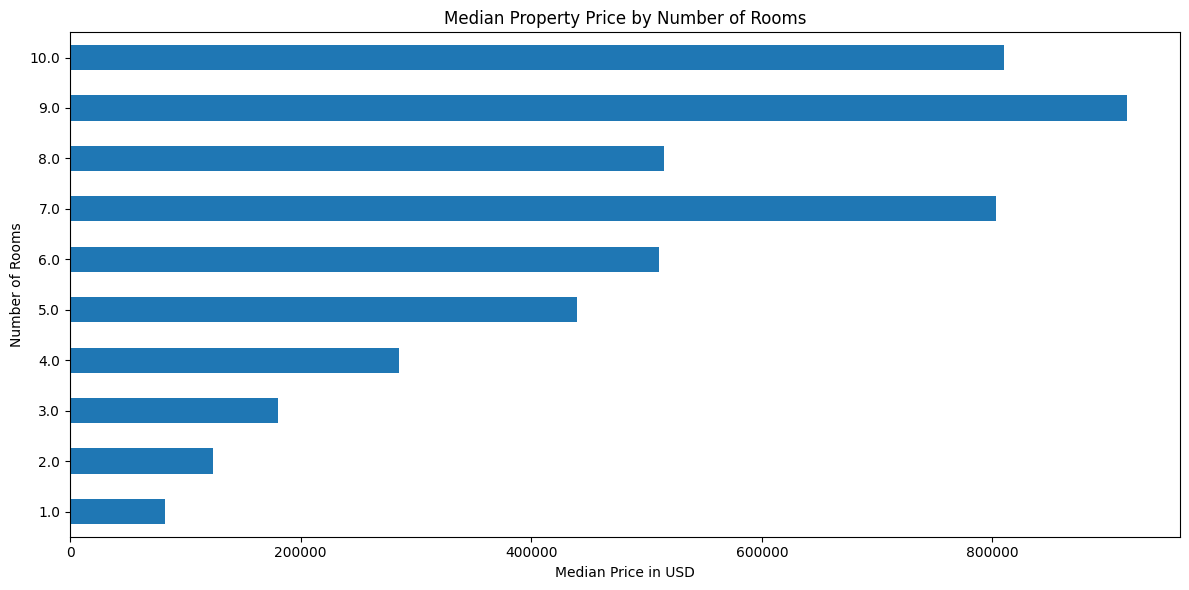

In [61]:
price_by_room['median'].plot(
    kind='barh', 
    figsize=(12, 6)
)

plt.title('Median Property Price by Number of Rooms')
plt.xlabel('Median Price in USD')
plt.ylabel('Number of Rooms')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [62]:
# Check metrics of construction year 
df['building_construction_year'].describe()

count    64719.000000
mean      1996.921754
std        157.527635
min          1.000000
25%       2004.000000
50%       2021.000000
75%       2024.000000
max       2316.000000
Name: building_construction_year, dtype: float64

In [63]:
# Check first 20 entries 
df['building_construction_year'].value_counts().sort_index().head(20)

building_construction_year
1.0     15
2.0     42
3.0     56
4.0     78
5.0     44
6.0     32
7.0     24
8.0     29
9.0      5
10.0    32
11.0     9
12.0     3
13.0     4
14.0     4
15.0     4
16.0     2
19.0     1
20.0     1
29.0     1
30.0     2
Name: count, dtype: int64

In [64]:
# Inspection of entries with building year < 1900
df[df['building_construction_year'] < 1900][
    ['country', 'location', 'building_construction_year', 'price_in_USD']
].sort_values('building_construction_year').head(20)

,country,location,building_construction_year,price_in_USD
119811,Poland,"Marki, Masovian Voivodeship, Wołomin County, P...",1.0,240969.0
119765,Poland,"Masovian Voivodeship, Warsaw, Poland",1.0,172816.0
119863,Poland,"Marki, Masovian Voivodeship, Wołomin County, P...",1.0,145987.0
120776,Poland,"Masovian Voivodeship, Warsaw, Poland",1.0,2068925.0
50789,Hungary,"Koeszeg, Transdanubia, Koszegi jaras, Vas, Hun...",1.0,115392.0
120450,Poland,"Piastow, Masovian Voivodeship, Pruszków County...",1.0,292084.0
50031,Hungary,"Transdanubia, Budapest, Komarom-Esztergom, Hun...",1.0,90874.0
120445,Poland,"Masovian Voivodeship, Warsaw, Poland",1.0,356585.0
120352,Poland,"Marki, Masovian Voivodeship, Wołomin County, P...",1.0,240969.0
120382,Poland,"Masovian Voivodeship, Warsaw, Poland",1.0,243160.0


In [65]:
# Inspection of entries with building year over 2026
df[df['building_construction_year'] > 2026][
    ['country', 'location', 'building_construction_year', 'price_in_USD']
].sort_values('building_construction_year', ascending=False).head(20)

,country,location,building_construction_year,price_in_USD
42033,Hungary,"Toekoel, Central Hungary, Szigetszentmiklosi j...",2316.0,136092.0
131510,UAE,"Dubai, UAE",2028.0,920460.0
131525,UAE,"Dubai, UAE",2028.0,912298.0
131304,UAE,"Dubai, UAE",2028.0,1354764.0
130378,UAE,"Dubai, UAE",2028.0,269589.0
133373,Thailand,"Chon Buri Province, Pattaya, Thailand",2028.0,109234.0
133359,Thailand,"Chon Buri Province, Pattaya, Thailand",2028.0,86500.0
133356,Thailand,"Chon Buri Province, Pattaya, Thailand",2028.0,173600.0
133404,Thailand,"Chon Buri Province, Pattaya, Thailand",2028.0,58400.0
133261,Thailand,"Chon Buri Province, Pattaya, Thailand",2028.0,108700.0


In [66]:
# Cutoff entries which are not between 1800 and 2028 
df['building_construction_year_analysis'] = df[
    'building_construction_year'
].where(df['building_construction_year'].between(1800, 2028))

In [67]:
# Check metrics of new column
df['building_construction_year_analysis'].describe()

count    64283.000000
mean      2009.260131
std         25.149809
min       1800.000000
25%       2004.500000
50%       2021.000000
75%       2024.000000
max       2028.000000
Name: building_construction_year_analysis, dtype: float64

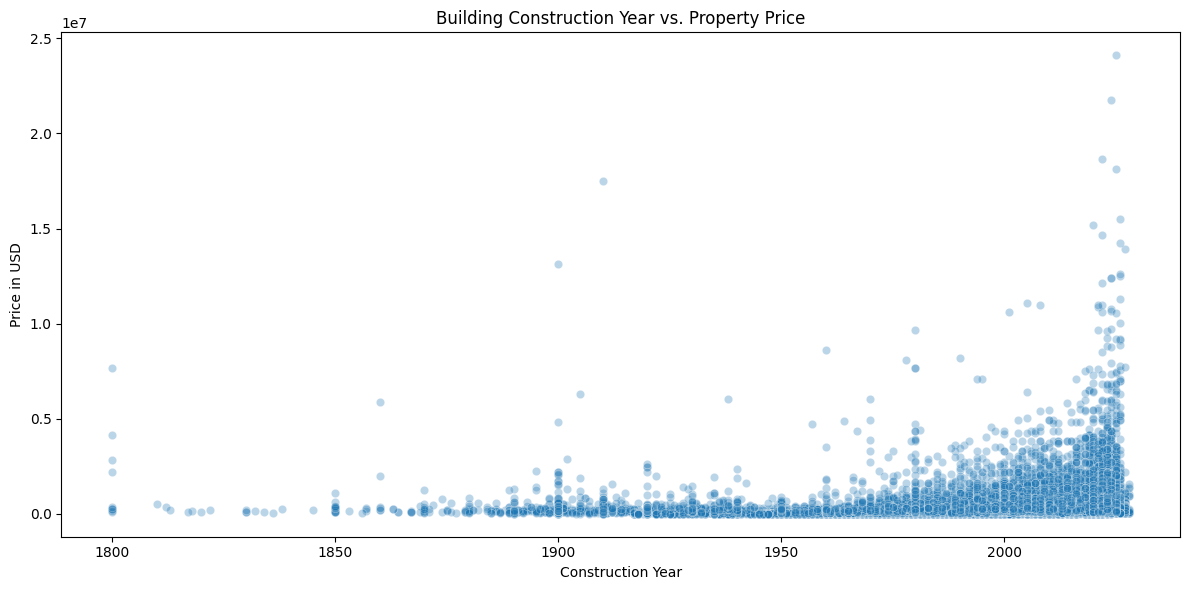

In [68]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='building_construction_year_analysis', 
    y='price_in_USD', 
    alpha=0.3
)

plt.title('Building Construction Year vs. Property Price')
plt.xlabel('Construction Year')
plt.ylabel('Price in USD')
plt.tight_layout()
plt.show()

### Relationship Between Construction Year and Property Price

The scatterplot shows a generally positive relationship between construction year and property price. Newer properties tend to have higher prices, although there is considerable variation.

The majority of properties are concentrated in the lower price range, while several high-priced outliers extend to more than **$20 million**. The spread of prices also appears to increase for newer properties.

Overall, construction year appears to have an influence on property prices, but it is not the only factor determining the price.

In [69]:
# Correlation check pearson method
correlation_year_pearson = df[
    ['building_construction_year_analysis', 'price_in_USD']
].corr(method='pearson')

correlation_year_pearson

,building_construction_year_analysis,price_in_USD
building_construction_year_analysis,1.000000,0.050161
price_in_USD,0.050161,1.000000


In [70]:
# Correlation check spearman method
correlation_year_spearman = df[
    ['building_construction_year_analysis', 'price_in_USD']
].corr(method='spearman')

correlation_year_spearman

,building_construction_year_analysis,price_in_USD
building_construction_year_analysis,1.000000,0.096106
price_in_USD,0.096106,1.000000


### Correlation Between Construction Year and Property Price

The Pearson correlation coefficient is **0.050**, indicating almost no linear relationship between construction year and property price.

The Spearman correlation coefficient is **0.096**, showing only a very weak positive monotonic relationship.

Although the scatterplot suggested that newer properties may tend to have higher prices, the correlation analysis shows that construction year alone has only a limited relationship with property price.

This suggests that other factors, such as location, apartment size, number of rooms and price per square meter, are likely more important predictors of property prices.

In [71]:
# Check metrcis of apartment bedrooms
df['apartment_bedrooms'].describe()

count    36982.000000
mean         2.289222
std         18.276913
min         -1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max       2009.000000
Name: apartment_bedrooms, dtype: float64

In [72]:
df['apartment_bedrooms'].value_counts().sort_index()

apartment_bedrooms
-1.0          37
 1.0       11269
 2.0       14433
 3.0        8550
 4.0        1968
 5.0         459
 6.0         141
 7.0          46
 8.0          22
 9.0           9
 10.0         13
 11.0          6
 12.0          4
 13.0          1
 14.0          4
 15.0          2
 16.0          3
 17.0          1
 20.0          1
 24.0          1
 25.0          1
 35.0          2
 41.0          1
 43.0          1
 45.0          1
 55.0          1
 70.0          1
 500.0         1
 2004.0        1
 2006.0        1
 2009.0        1
Name: count, dtype: int64

In [73]:
# Check entries with over 10 bedrooms
df[df['apartment_bedrooms'] >= 10][
    ['country', 'location', 'apartment_bedrooms', 'apartment_total_area_analysis', 'price_in_USD']
].sort_values('apartment_bedrooms', ascending=False).head(20)

,country,location,apartment_bedrooms,apartment_total_area_analysis,price_in_USD
28866,Greece,Greece,2009.0,90.0,270645.0
144030,Greece,Greece,2006.0,95.0,273240.0
31870,Greece,Greece,2004.0,120.0,184778.0
20854,Montenegro,Montenegro,500.0,88.0,217386.0
109841,Spain,"Castell-Platja d Aro, Catalonia, Lower Empordà...",70.0,NaN,4458589.0
4350,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",55.0,440.0,2512417.0
4487,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",45.0,242.0,4021634.0
95192,Spain,"Valencian Community, Alicante, Provincia de Al...",43.0,NaN,2403423.0
138180,Spain,"Castell-Platja d Aro, Catalonia, Lower Empordà...",41.0,NaN,1882515.0
9033,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",35.0,166.0,1205403.0


In [74]:
# Cutoff extrem outliers
df['apartment_bedrooms_analysis'] = df['apartment_bedrooms'].where(df['apartment_bedrooms'].between(1,10))

In [75]:
# Check metrics again
df['apartment_bedrooms_analysis'].describe()

count    36910.000000
mean         2.099892
std          1.000213
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         10.000000
Name: apartment_bedrooms_analysis, dtype: float64

In [76]:
# Check price by bathrooms
price_by_bedrooms = (
    df.groupby('apartment_bedrooms_analysis')['price_in_USD']
    .agg(['count', 'median', 'mean'])
)

price_by_bedrooms

,count,median,mean
apartment_bedrooms_analysis,,,
1.0,11077,136953.0,1.918004e+05
2.0,14278,244559.0,3.572889e+05
3.0,8494,374990.0,5.697145e+05
4.0,1955,576072.0,1.080980e+06
5.0,458,901349.0,2.046279e+06
6.0,141,990978.0,2.062511e+06
7.0,46,904793.5,2.029984e+06
8.0,22,570637.0,7.559549e+05
9.0,9,683873.0,1.872572e+06


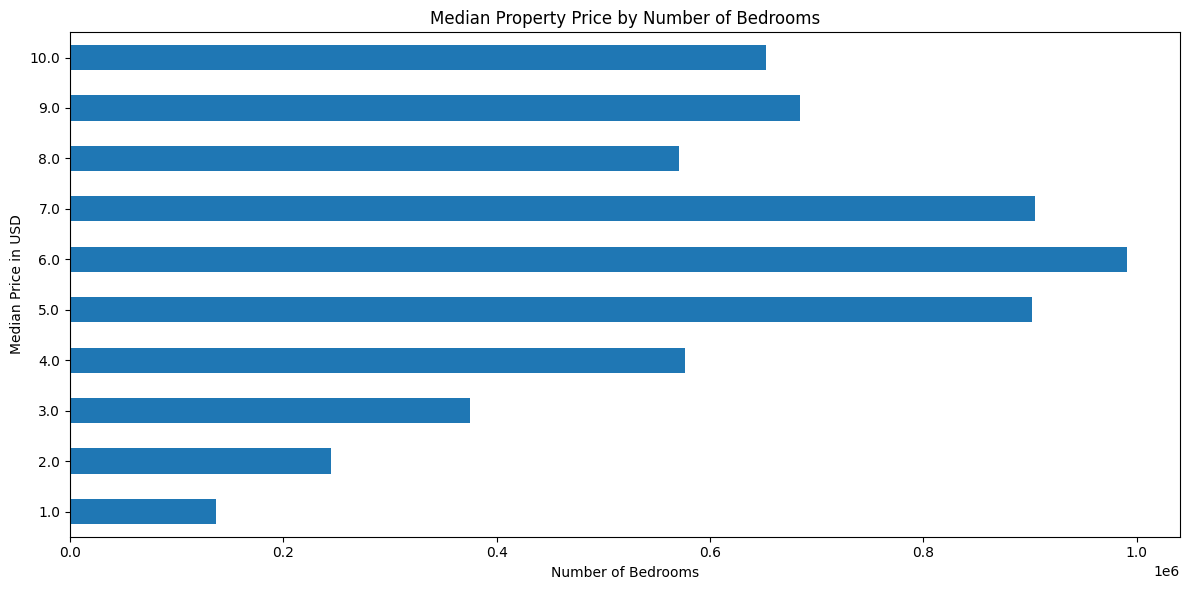

In [77]:
# Plot price by bedroomos
price_by_bedrooms['median'].plot(
    kind='barh', 
    figsize=(12,6)
)

plt.title('Median Property Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Median Price in USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Median Property Price by Number of Bedrooms

The median property price generally increases with the number of bedrooms, particularly from **1 to 7 bedrooms**.

Properties with **6–7 bedrooms** show the highest median prices. For properties with more than 7 bedrooms, the results become less stable due to the small number of observations.

Overall, the analysis suggests a positive relationship between the number of bedrooms and property price, although other factors such as location and apartment size also play an important role.df['apartment_bathrooms'].value_counts().sort_index()

In [78]:
# Check metrics of apartment bathrooms
df['apartment_bathrooms'].describe()

count    55973.000000
mean         1.364229
std          0.745019
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         43.000000
Name: apartment_bathrooms, dtype: float64

In [79]:
df['apartment_bathrooms'].value_counts().sort_index()

apartment_bathrooms
1.0     39750
2.0     13568
3.0      1883
4.0       506
5.0       126
6.0        69
7.0        21
8.0        12
9.0         7
10.0       12
11.0        4
12.0        1
13.0        2
14.0        4
17.0        3
21.0        2
27.0        1
30.0        1
43.0        1
Name: count, dtype: int64

In [80]:
# Check entries with over 10 bathrooms
df[df['apartment_bathrooms'] >= 10][
    ['country', 'location', 'apartment_bathrooms', 'apartment_total_area_analysis', 'price_in_USD']
].sort_values('apartment_bathrooms', ascending=False).head(20)

,country,location,apartment_bathrooms,apartment_total_area_analysis,price_in_USD
95192,Spain,"Valencian Community, Alicante, Provincia de Al...",43.0,NaN,2403423.0
45557,Hungary,"Hajduszoboszlo, Great Plain and North, Hajdusz...",30.0,NaN,1568409.0
109396,Spain,"Castell-Platja d Aro, Catalonia, Lower Empordà...",27.0,NaN,945340.0
26562,Turkey,"Ciplakli, Mediterranean Region, Alanya, Turkey",21.0,120.0,186952.0
17022,Turkey,"Akarca, Central Anatolia Region, Turkey",21.0,78.0,95106.0
52133,Hungary,"Transdanubia, Budapest, Komarom-Esztergom, Hun...",17.0,390.0,1327014.0
20530,Montenegro,"Sustas, Bar Municipality, Montenegro",17.0,NaN,586941.0
115559,Croatia,"Zagreb, Croatia",17.0,435.0,597810.0
116047,Latvia,"Vidzeme, Jurmala, Latvia",14.0,NaN,2499935.0
29707,Greece,"Polychrono, Macedonia and Thrace, Municipality...",14.0,450.0,1630392.0


In [81]:
# Cutoff extrem outliers
df['apartment_bathrooms_analysis'] = df['apartment_bathrooms'].where(df['apartment_bathrooms'].between(1,10))

In [82]:
# Check metrics after cutoff 
df['apartment_bathrooms_analysis'].describe()

count    55954.000000
mean         1.358777
std          0.667853
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: apartment_bathrooms_analysis, dtype: float64

In [83]:
# Check price by bathrooms
price_by_bathrooms = (
    df.groupby('apartment_bathrooms_analysis')['price_in_USD']
    .agg(['count', 'median', 'mean'])
)

price_by_bathrooms

,count,median,mean
apartment_bathrooms_analysis,,,
1.0,39619,129008.0,1.671161e+05
2.0,13522,281514.0,3.679427e+05
3.0,1877,551578.0,8.286719e+05
4.0,504,1033866.0,1.975236e+06
5.0,126,1265777.5,2.999150e+06
6.0,69,1249967.0,3.786045e+06
7.0,21,1630392.0,5.915765e+06
8.0,12,948345.0,1.249174e+06
9.0,7,1304314.0,3.075300e+06


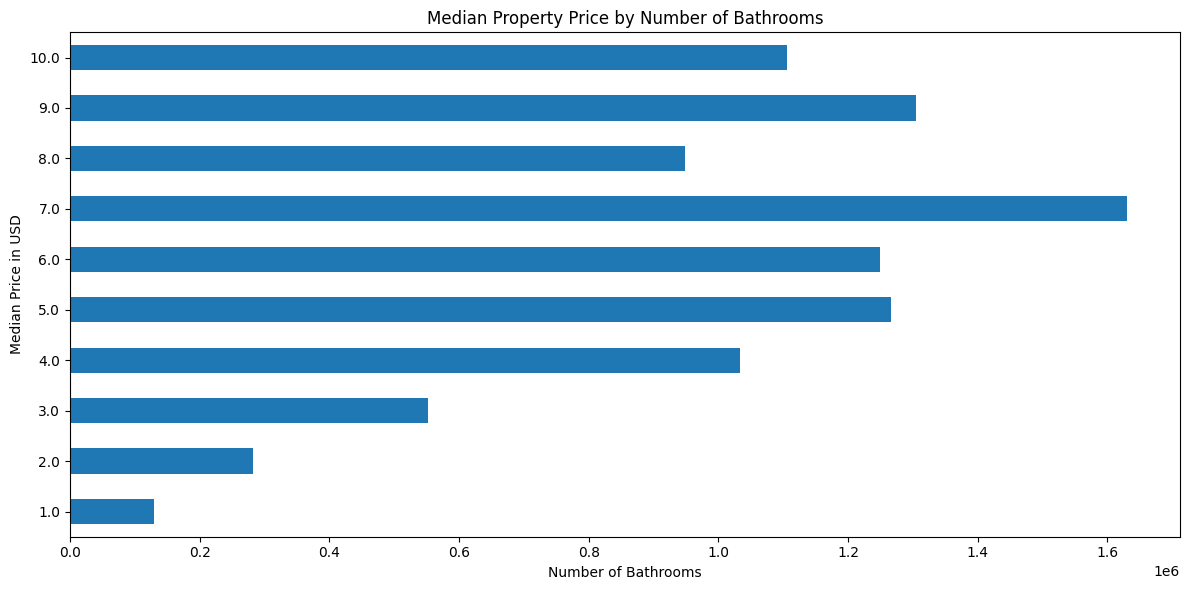

In [84]:
# Plot price by bathrooms
price_by_bathrooms['median'].plot(
    kind='barh', 
    figsize=(12,6)
)

plt.title('Median Property Price by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Median Price in USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Median Property Price by Number of Bathrooms

The median property price generally increases as the number of bathrooms increases.

Properties with **1–4 bathrooms** show a particularly clear increase in median price. For properties with more than 4 bathrooms, the number of observations becomes much smaller, making the results more variable and less reliable.

Overall, the analysis suggests that the number of bathrooms is positively associated with property price.# Check for unique locations
df['location'].nunique()

In [85]:
# Check for unique locations
df['location'].nunique()

7445

In [86]:
df['location'].value_counts().head(20)

location
Mediterranean Region, Sekerhane Mahallesi, Alanya, Turkey                                                        7244
Central Federal District, poselenie Sosenskoe, Novomoskovsky Administrative Okrug, Russia                        7023
Minsk, Belarus                                                                                                   4535
Central Hungary, Budapest, Komarom-Esztergom, Hungary                                                            4366
Kommunarka, Central Federal District, poselenie Sosenskoe, Novomoskovsky Administrative Okrug, Russia            2681
Transdanubia, Budapest, Komarom-Esztergom, Hungary                                                               2527
Dubai, UAE                                                                                                       2477
Montenegro                                                                                                       2190
Brest Region, Brest, Belarus                   

In [87]:
# Check property prices by location
location_price = (
    df.groupby('location')['price_in_USD']
    .agg(['count', 'median', 'mean'])
    .sort_values('count', ascending=False)
)

location_price_filtered = location_price[
    location_price['count'] > 500
]

location_price_filtered

,count,median,mean
location,,,
"Mediterranean Region, Sekerhane Mahallesi, Alanya, Turkey",7231,197909.0,3.006525e+05
"Central Federal District, poselenie Sosenskoe, Novomoskovsky Administrative Okrug, Russia",7023,127223.0,1.318499e+05
"Central Hungary, Budapest, Komarom-Esztergom, Hungary",4365,190776.0,2.753151e+05
"Minsk, Belarus",4234,73900.0,9.719698e+04
"Kommunarka, Central Federal District, poselenie Sosenskoe, Novomoskovsky Administrative Okrug, Russia",2681,125891.0,1.305432e+05
"Transdanubia, Budapest, Komarom-Esztergom, Hungary",2525,152687.0,2.058474e+05
"Dubai, UAE",2476,535414.5,1.367220e+06
Montenegro,2189,293471.0,5.167479e+05
"Brest Region, Brest, Belarus",2130,50000.0,6.593004e+04


In [88]:
location_price_filtered.head(20)

,count,median,mean
location,,,
"Mediterranean Region, Sekerhane Mahallesi, Alanya, Turkey",7231,197909.0,3.006525e+05
"Central Federal District, poselenie Sosenskoe, Novomoskovsky Administrative Okrug, Russia",7023,127223.0,1.318499e+05
"Central Hungary, Budapest, Komarom-Esztergom, Hungary",4365,190776.0,2.753151e+05
"Minsk, Belarus",4234,73900.0,9.719698e+04
"Kommunarka, Central Federal District, poselenie Sosenskoe, Novomoskovsky Administrative Okrug, Russia",2681,125891.0,1.305432e+05
"Transdanubia, Budapest, Komarom-Esztergom, Hungary",2525,152687.0,2.058474e+05
"Dubai, UAE",2476,535414.5,1.367220e+06
Montenegro,2189,293471.0,5.167479e+05
"Brest Region, Brest, Belarus",2130,50000.0,6.593004e+04


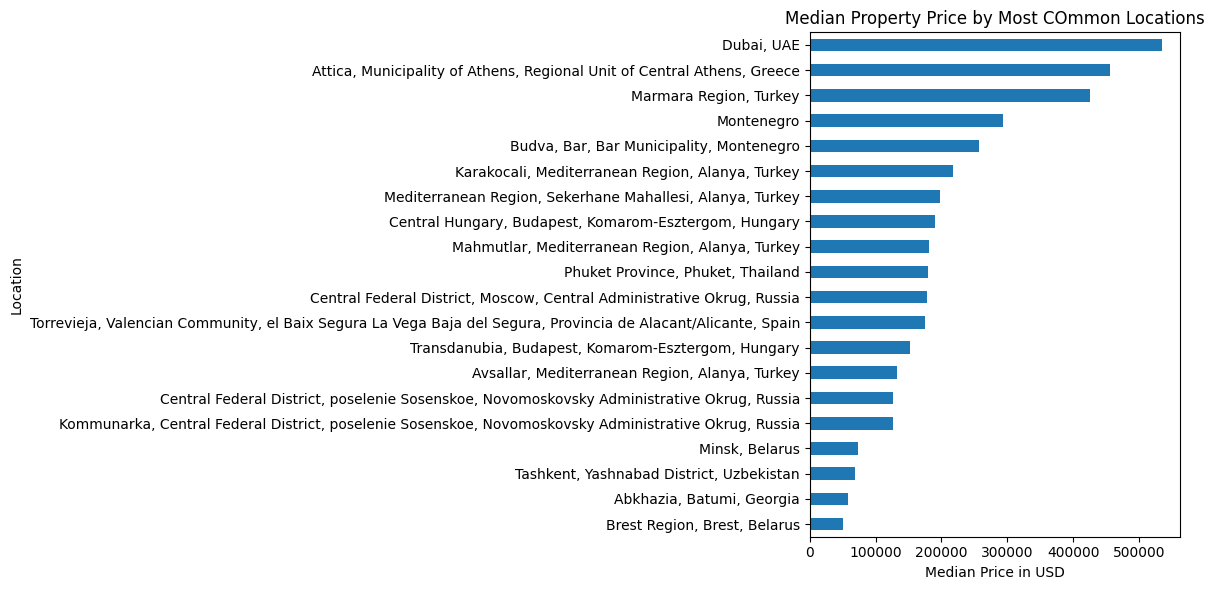

In [89]:
top_locations = location_price_filtered.head(20)

top_locations['median'].sort_values().plot(
    kind='barh',
    figsize=(12, 6)
)

plt.title('Median Property Price by Most COmmon Locations')
plt.xlabel('Median Price in USD')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

### Median Property Price by Most Common Locations

The comparison shows substantial differences in median property prices between the most frequently represented locations.

- **Dubai** has the highest median property price at approximately **$535,000**.
- **Attica (Athens)** and the **Marmara Region** also show relatively high median prices.
- Locations in **Belarus, Uzbekistan and Georgia** have considerably lower median property prices.
- The results indicate that **location is an important factor in property prices** within this dataset.

Only locations with at least **500 observations** were considered, reducing the influence of locations with very small sample sizes.# Inspection of apartment floor
df['apartment_floor'].describe()

In [90]:
# Inspection of apartment floor
df['apartment_floor'].describe()

count    54592.000000
mean         5.791709
std          5.541368
min         -2.000000
25%          2.000000
50%          4.000000
75%          8.000000
max        202.000000
Name: apartment_floor, dtype: float64

In [91]:
df['apartment_floor'].value_counts().sort_index()

apartment_floor
-2.0         1
-1.0       414
 1.0      9257
 2.0      7994
 3.0      6847
          ... 
 80.0        1
 82.0        1
 90.0        1
 105.0       1
 202.0       1
Name: count, Length: 70, dtype: int64

In [92]:
# Inspection extrem outliers 
df[df['apartment_floor'] >= 50][
    ['country', 'location', 'apartment_floor',
     'building_total_floors', 'apartment_total_area_analysis',
     'price_in_USD']
].sort_values(
    'apartment_floor', ascending=False
)

,country,location,apartment_floor,building_total_floors,apartment_total_area_analysis,price_in_USD
132761,UAE,"Dubai, UAE",202.0,2.0,NaN,168983.0
27729,Montenegro,"Tivat, Tivat Municipality, Montenegro",105.0,3.0,105.0,400451.0
130893,UAE,"Dubai, UAE",90.0,104.0,NaN,1660136.0
130901,UAE,"Dubai, UAE",82.0,NaN,183.0,1822713.0
130638,UAE,"Dubai, UAE",80.0,80.0,245.0,596380.0
131173,UAE,"Dubai, UAE",74.0,83.0,NaN,7716103.0
134933,Thailand,"Chon Buri Province, Pattaya, Thailand",67.0,NaN,45.0,122530.0
134547,Thailand,"Chon Buri Province, Pattaya, Thailand",67.0,NaN,29.0,78964.0
133761,Thailand,"Chon Buri Province, Pattaya, Thailand",66.0,67.0,148.0,856073.0
130486,UAE,"Dubai, UAE",65.0,80.0,100.0,347888.0


In [93]:
df[df['apartment_floor'] <0] [
    ['country', 'location', 'apartment_floor',
     'building_total_floors', 'price_in_USD']
]

,country,location,apartment_floor,building_total_floors,price_in_USD
24970,Uzbekistan,"Tashkent, Yashnabad District, Uzbekistan",-1.0,15.0,101486.0
25252,Uzbekistan,"Tashkent, Yashnabad District, Uzbekistan",-1.0,15.0,40296.0
25409,Uzbekistan,"Tashkent, Yashnabad District, Uzbekistan",-1.0,15.0,40296.0
25427,Uzbekistan,"Tashkent, Yashnabad District, Uzbekistan",-1.0,15.0,38320.0
25467,Uzbekistan,"Tashkent, Yashnabad District, Uzbekistan",-1.0,15.0,40296.0
...,...,...,...,...,...
130118,Greece,"Triad, Macedonia and Thrace, Municipality of T...",-1.0,NaN,513690.0
130119,Greece,"Nikiti, Macedonia and Thrace, The Municipality...",-1.0,NaN,434771.0
130131,Greece,"Chaniotis, Macedonia and Thrace, Municipality ...",-1.0,NaN,596724.0
130135,Greece,"Macedonia and Thrace, Municipality of Kassandr...",-1.0,NaN,524620.0


In [94]:
invalid_floor = df[
    (df['apartment_floor'] > df['building_total_floors']) &
    (df['building_total_floors'].notna())
]

len(invalid_floor)

1195

In [95]:
df['apartment_floor_analysis'] = df['apartment_floor'].where(
    ~(
        (df['apartment_floor'] > df['building_total_floors'])  &
        (df['building_total_floors'].notna())
    )
)

In [96]:
# Check metrics again
df['apartment_floor_analysis'].describe()

count    53397.000000
mean         5.815027
std          5.474373
min         -2.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         90.000000
Name: apartment_floor_analysis, dtype: float64

In [97]:
df['apartment_floor_analysis'].isna().sum()

np.int64(94139)

In [98]:
# Exclude -2 in the dataframe
df['apartment_floor_analysis'] = df['apartment_floor_analysis'].where(
    df['apartment_floor_analysis'] >= -1
)

In [99]:
# Check metrics again
df['apartment_floor_analysis'].describe()

count    53396.000000
mean         5.815173
std          5.474320
min         -1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         90.000000
Name: apartment_floor_analysis, dtype: float64

In [100]:
# Check price by floor
price_by_floor = (
    df.groupby('apartment_floor_analysis')['price_in_USD']
    .agg(['count', 'median', 'mean'])
)

price_by_floor

,count,median,mean
apartment_floor_analysis,,,
-1.0,414,601127.0,9.996022e+05
1.0,9199,158146.0,2.580517e+05
2.0,7517,142388.0,2.233562e+05
3.0,6551,144440.0,2.325745e+05
4.0,5201,141301.0,2.049945e+05
...,...,...,...
67.0,2,100747.0,1.007470e+05
74.0,1,7716103.0,7.716103e+06
80.0,1,596380.0,5.963800e+05


In [101]:
floor_filtered = price_by_floor[price_by_floor['count'] >= 100]

floor_filtered

,count,median,mean
apartment_floor_analysis,,,
-1.0,414,601127.0,999602.164251
1.0,9199,158146.0,258051.668551
2.0,7517,142388.0,223356.178130
3.0,6551,144440.0,232574.496871
4.0,5201,141301.0,204994.477216
5.0,4269,126084.0,190552.831811
6.0,2613,125224.0,182337.363567
7.0,2237,111353.0,182458.128744
8.0,2371,118176.0,176130.864192


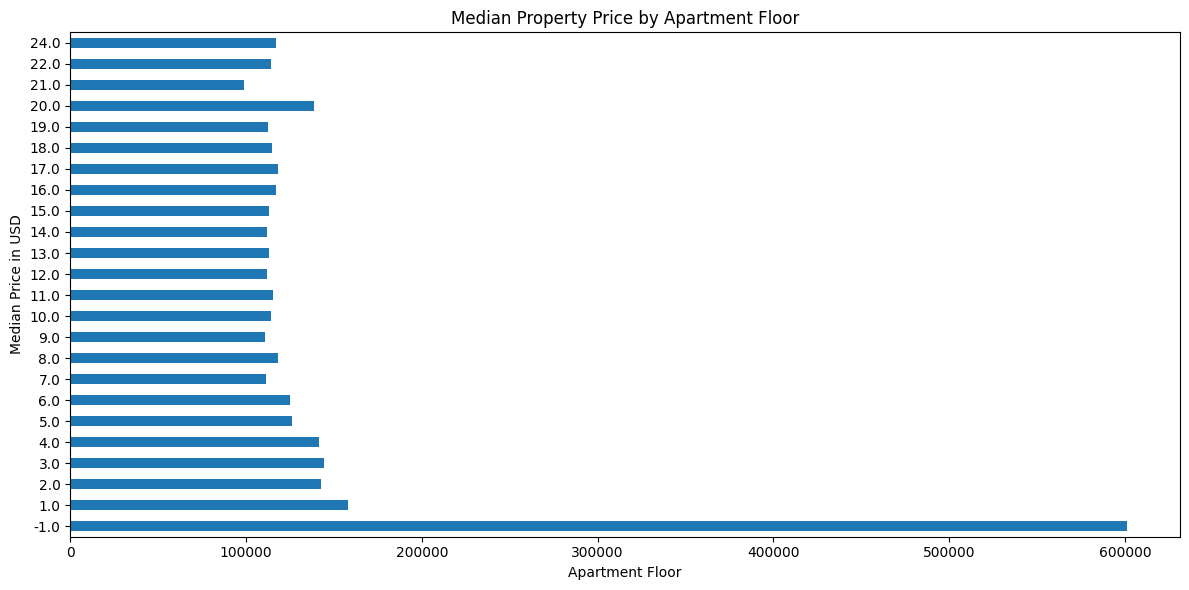

In [102]:
floor_filtered['median'].plot(
    kind='barh', 
    figsize=(12, 6)
)

plt.title('Median Property Price by Apartment Floor')
plt.xlabel('Apartment Floor')
plt.ylabel('Median Price in USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Median Property Price by Apartment Floor

The analysis shows that most properties are located on lower floors, particularly between the 1st and 8th floors.

The median property prices for the regular floors are relatively similar, although some variation can be observed between individual floors. There is no clear linear increase in property prices with higher floors within the observed data.

The value **-1** represents a potential basement or below-ground floor. However, its median property price is substantially higher than that of the regular floors. This suggests that the value may represent a specific subset of properties rather than a general price effect of being located below ground.

Therefore, the value **-1** should be treated as a separate category rather than interpreted as a regular apartment floor. The very high floors also contain only a small number of observations and should therefore be interpreted with caution.

In [103]:
# Exclude the negative floor from analysis
floor_filtered_normal = price_by_floor[
    (price_by_floor.index >= 1) &
    (price_by_floor['count'] >= 100)
]

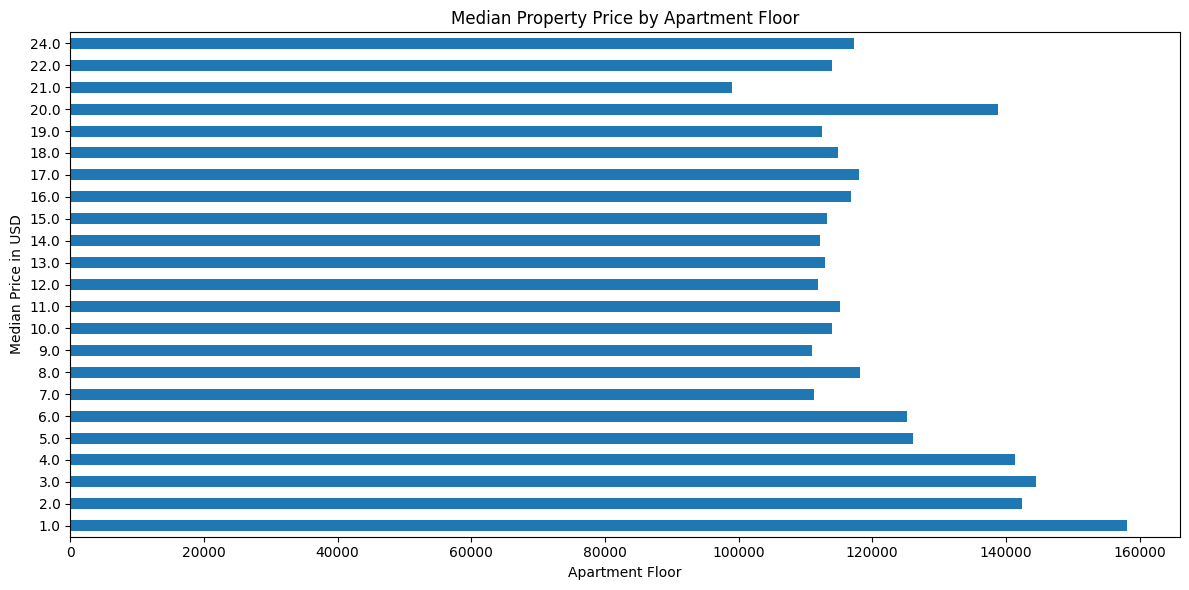

In [104]:
floor_filtered_normal['median'].plot(
    kind='barh', 
    figsize=(12, 6)
)

plt.title('Median Property Price by Apartment Floor')
plt.xlabel('Apartment Floor')
plt.ylabel('Median Price in USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Median Property Price by Apartment Floor

The analysis shows that property prices do not increase consistently with higher apartment floors.

The median prices vary between individual floors, but there is no clear linear trend. Lower floors show relatively high median prices, while the median prices of higher floors fluctuate within a comparatively similar range.

Only floors with at least **100 observations** were included in the visualization to reduce the influence of floors with very few properties.

Overall, apartment floor appears to have a less consistent relationship with property price than factors such as apartment area, location, number of rooms or number of bathrooms.# Correlation check

correlation_cols = [
    'building_construction_year_analysis', 
    'building_total_floors', 
    'apartment_floor_analysis', 
    'apartment_rooms_analysis', 
    'apartment_bedrooms_analysis', 
    'apartment_bathrooms_analysis', 
    'apartment_total_area_analysis', 
    'price_in_USD'
]

correlation = df[correlation_cols].corr(method='spearman')

correlation['price_in_USD'].sort_values(ascending=False)

In [105]:
# Correlation check

correlation_cols = [
    'building_construction_year_analysis', 
    'building_total_floors', 
    'apartment_floor_analysis', 
    'apartment_rooms_analysis', 
    'apartment_bedrooms_analysis', 
    'apartment_bathrooms_analysis', 
    'apartment_total_area_analysis', 
    'price_in_USD'
]

correlation = df[correlation_cols].corr(method='spearman')

correlation['price_in_USD'].sort_values(ascending=False)

price_in_USD                           1.000000
apartment_total_area_analysis          0.701062
apartment_bathrooms_analysis           0.548583
apartment_rooms_analysis               0.527809
apartment_bedrooms_analysis            0.527069
building_construction_year_analysis    0.096106
apartment_floor_analysis              -0.154317
building_total_floors                 -0.329986
Name: price_in_USD, dtype: float64

### Correlation Overview

The Spearman correlation analysis shows that **apartment total area** has the strongest positive relationship with property price, with a correlation coefficient of **0.701**.

The number of **bathrooms (0.549)**, **rooms (0.528)** and **bedrooms (0.527)** also show moderate positive relationships with property price.

In contrast, **construction year (0.096)** shows only a very weak positive relationship with price. This confirms the previous analysis that the construction year alone has limited explanatory power.

The variables **apartment floor (-0.154)** and **building total floors (-0.330)** show negative relationships with price. These results should be interpreted with caution, as correlations do not imply causation and may be influenced by other factors such as country, location and property characteristics.

Overall, the correlation analysis suggests that **apartment size, number of rooms and number of bathrooms are more strongly associated with property price than construction year or floor-related variables**.

## EDA Conclusion

The Exploratory Data Analysis revealed several important characteristics of the real estate dataset.

### Data Quality

Several data quality issues were identified, including invalid or implausible values in area, room, bedroom, bathroom, construction year and floor-related variables. Instead of removing values automatically, the variables were investigated individually and separate `_analysis` columns were created where appropriate.

Extreme values were particularly noticeable in **property area** and **price per square meter**. Very small apartment areas produced unrealistic price-per-square-meter values, while some extremely large areas appeared to be data quality issues. Appropriate analysis ranges were therefore applied while preserving the original variables.

### Property Price

Property prices show strong differences between countries and locations. The distributions are generally **right-skewed**, meaning that a relatively small number of very expensive properties can strongly influence the mean.

Therefore, the **median** was frequently used for comparisons because it provides a more representative measure of a typical property price in the presence of extreme values.

### Main Relationships with Price

The analysis indicates that **apartment total area** has the strongest relationship with property price. The Spearman correlation between apartment area and price is **0.701**.

The number of **bathrooms (0.549)**, **rooms (0.528)** and **bedrooms (0.527)** also show moderate positive relationships with price.

In contrast, **construction year (0.096)** shows only a very weak relationship with price. Floor-related variables also show weaker and less consistent relationships.

### Location

Location appears to be an important factor in property prices. Both country-level and location-level analyses showed substantial differences in median property prices.

This suggests that geographical information should be considered when developing predictive models.

### Overall Conclusion

The EDA suggests that property price is influenced by **multiple factors rather than a single variable**. Apartment size, number of rooms and bathrooms, as well as geographical information, appear particularly relevant.

The dataset contains enough variation and complexity to apply machine learning methods. However, the identified data quality issues need to be considered when preparing the features.

The next step is therefore **Feature Engineering**, where the cleaned variables will be transformed into suitable features for machine learning.

# Feature Engineering

In [106]:
# Check missing values
df.isna().sum().sort_values(ascending=False)

apartment_living_area                  119824
apartment_living_area_clean            119824
apartment_bedrooms_analysis            110626
apartment_bedrooms                     110554
apartment_floor_analysis                94140
apartment_floor                         92944
apartment_bathrooms_analysis            91582
apartment_bathrooms                     91563
building_construction_year_analysis     83253
building_construction_year              82817
building_total_floors                   79312
apartment_rooms_analysis                73438
apartment_rooms                         73358
price_per_sqm_analysis                  11415
price_per_sqm                           10969
apartment_total_area_sqm_analysis       10032
apartment_total_area_analysis            9596
apartment_total_area_clean               5740
apartment_total_area                     5740
price_in_USD                             2575
location                                  131
country                           

In [107]:
# Check mean missing values
df.isna().mean().sort_values(ascending=False) * 100

apartment_living_area                  81.216788
apartment_living_area_clean            81.216788
apartment_bedrooms_analysis            74.982377
apartment_bedrooms                     74.933576
apartment_floor_analysis               63.808155
apartment_floor                        62.997506
apartment_bathrooms_analysis           62.074341
apartment_bathrooms                    62.061463
building_construction_year_analysis    56.428939
building_construction_year             56.133418
building_total_floors                  53.757727
apartment_rooms_analysis               49.776326
apartment_rooms                        49.722102
price_per_sqm_analysis                  7.737095
price_per_sqm                           7.434796
apartment_total_area_sqm_analysis       6.799696
apartment_total_area_analysis           6.504175
apartment_total_area_clean              3.890576
apartment_total_area                    3.890576
price_in_USD                            1.745337
location            

In [108]:
# Drop missing rows from price_in_USD
df = df.dropna(subset=['price_in_USD'])

In [109]:
# Check 
df['price_in_USD'].isna().sum()

np.int64(0)

In [110]:
# Drop apartment living area, because of 81% missing values
df = df.drop(columns='apartment_living_area')

In [111]:
# Check missing values
df.isna().sum().sort_values(ascending=False)

apartment_living_area_clean            117769
apartment_bedrooms_analysis            108468
apartment_bedrooms                     108397
apartment_floor_analysis                91932
apartment_floor                         90832
apartment_bathrooms_analysis            89192
apartment_bathrooms                     89173
building_construction_year_analysis     81099
building_construction_year              80665
building_total_floors                   77376
apartment_rooms_analysis                71427
apartment_rooms                         71350
price_per_sqm_analysis                   8840
apartment_total_area_sqm_analysis        8829
price_per_sqm                            8394
apartment_total_area_analysis            8394
apartment_total_area_clean               4706
apartment_total_area                     4706
location                                  131
country                                   130
title                                       0
url                               

In [112]:
# Drop url, image and title cols
df = df.drop(columns=['url', 'image', 'title'])

In [113]:
# Check shape
print(f'Rows: {df.shape[0]} -- Columns: {df.shape[1]}')

Rows: 144961 -- Columns: 21


In [114]:
df.isna().sum().sort_values(ascending=False)

apartment_living_area_clean            117769
apartment_bedrooms_analysis            108468
apartment_bedrooms                     108397
apartment_floor_analysis                91932
apartment_floor                         90832
apartment_bathrooms_analysis            89192
apartment_bathrooms                     89173
building_construction_year_analysis     81099
building_construction_year              80665
building_total_floors                   77376
apartment_rooms_analysis                71427
apartment_rooms                         71350
price_per_sqm_analysis                   8840
apartment_total_area_sqm_analysis        8829
apartment_total_area_analysis            8394
price_per_sqm                            8394
apartment_total_area                     4706
apartment_total_area_clean               4706
location                                  131
country                                   130
price_in_USD                                0
dtype: int64

In [115]:
# Check nunique on country and location
df[['country', 'location']].nunique()

country       27
location    7188
dtype: int64

In [116]:
# Correlation check for missing values
missing_feat = [
    'apartment_bedrooms',
    'apartment_floor',
    'apartment_bathrooms',
    'building_construction_year',
    'building_total_floors',
    'apartment_rooms',
    'apartment_total_area'
]

df[missing_feat].isna().corr()

,apartment_bedrooms,apartment_floor,apartment_bathrooms,building_construction_year,building_total_floors,apartment_rooms,apartment_total_area
apartment_bedrooms,1.000000,-0.041742,0.410535,-0.131587,-0.056015,0.143256,-0.015684
apartment_floor,-0.041742,1.000000,0.194201,0.302069,0.647568,0.545608,0.108573
apartment_bathrooms,0.410535,0.194201,1.000000,0.238118,0.029189,0.406614,0.044087
building_construction_year,-0.131587,0.302069,0.238118,1.000000,0.388751,0.236128,0.008015
building_total_floors,-0.056015,0.647568,0.029189,0.388751,1.000000,0.408635,0.106745
apartment_rooms,0.143256,0.545608,0.406614,0.236128,0.408635,1.000000,0.116996
apartment_total_area,-0.015684,0.108573,0.044087,0.008015,0.106745,0.116996,1.000000


In [117]:
# Change apartment total area into float
df['apartment_total_area_analysis'] = (
    df['apartment_total_area']
    .str.replace(' m²', '', regex=False)
    .str.replace(' ' , '', regex=False)
    .astype(float)
)

In [118]:
# Exclude extreme outliers
df['apartment_total_area_analysis'] = df[
    'apartment_total_area_analysis'
].where(df['apartment_total_area_analysis'] <= 500
)

In [119]:
df['apartment_rooms_analysis'] = df['apartment_rooms'].where(
    df['apartment_rooms'].between(1, 10)
)

In [120]:
df['apartment_bedrooms_analysis'] = df['apartment_bedrooms'].where(
    df['apartment_bedrooms'].between(1, 10)
)

In [121]:
df['apartment_bathrooms_analysis'] = df['apartment_bathrooms'].where(
    df['apartment_bathrooms'].between(1, 10)
)

In [122]:
df['building_construction_year_analysis'] = df[
    'building_construction_year'
].where(
    df['building_construction_year'].between(1800, 2028)
)

In [123]:
df['apartment_floor_analysis'] = df['apartment_floor'].where(
    ~(
        (df['apartment_floor'] > df['building_total_floors']) &
        (df['building_total_floors'].notna())
    )
)

In [124]:
df['apartment_floor_analysis'] = df[
    'apartment_floor_analysis'
].where(
    df['apartment_floor_analysis'] >= -1
)

In [125]:
analysis_features = [
    'apartment_total_area_analysis',
    'apartment_rooms_analysis',
    'apartment_bedrooms_analysis',
    'apartment_bathrooms_analysis',
    'building_construction_year_analysis',
    'apartment_floor_analysis'
]

df[analysis_features].describe()

,apartment_total_area_analysis,apartment_rooms_analysis,apartment_bedrooms_analysis,apartment_bathrooms_analysis,building_construction_year_analysis,apartment_floor_analysis
count,136567.000000,73534.000000,36493.000000,55769.000000,63862.000000,53029.000000
mean,116.223180,2.560163,2.103965,1.358819,2009.274357,5.806653
std,89.829601,1.104530,1.001336,0.668076,25.177245,5.465215
min,1.000000,1.000000,1.000000,1.000000,1800.000000,-1.000000
25%,56.000000,2.000000,1.000000,1.000000,2005.000000,2.000000
50%,86.000000,2.000000,2.000000,1.000000,2022.000000,4.000000
75%,144.000000,3.000000,3.000000,2.000000,2024.000000,8.000000
max,500.000000,10.000000,10.000000,10.000000,2028.000000,90.000000


In [126]:
df[analysis_features].isna().sum().sort_values(ascending=False)

apartment_bedrooms_analysis            108468
apartment_floor_analysis                91932
apartment_bathrooms_analysis            89192
building_construction_year_analysis     81099
apartment_rooms_analysis                71427
apartment_total_area_analysis            8394
dtype: int64

In [127]:
# Filling apartment_total_area_analysis with median
df['apartment_total_area_analysis'] = (
    df['apartment_total_area_analysis']
    .fillna(df['apartment_total_area_analysis'].median())
)

In [128]:
# Check missing values
df[analysis_features].isna().sum().sort_values(ascending=False)

apartment_bedrooms_analysis            108468
apartment_floor_analysis                91932
apartment_bathrooms_analysis            89192
building_construction_year_analysis     81099
apartment_rooms_analysis                71427
apartment_total_area_analysis               0
dtype: int64

In [129]:
# Create missing value indicator column
df['apartment_rooms_missing'] = (
    df['apartment_rooms_analysis'].isna().astype(int)
)

In [130]:
# Fill the missing values in room analysis with median
df['apartment_rooms_analysis'] = (
    df['apartment_rooms_analysis']
    .fillna(df['apartment_rooms_analysis'].median())
)

In [131]:
# Create missing value indicator column
df['apartment_bedrooms_missing'] = (
    df['apartment_bedrooms_analysis'].isna().astype(int)
)

# Fill the missing values with median
df['apartment_bedrooms_analysis'] = (
    df['apartment_bedrooms_analysis']
    .fillna(df['apartment_bedrooms_analysis'].median())
)

In [132]:
# Check missing values
df[analysis_features].isna().sum().sort_values(ascending=False)

apartment_floor_analysis               91932
apartment_bathrooms_analysis           89192
building_construction_year_analysis    81099
apartment_total_area_analysis              0
apartment_rooms_analysis                   0
apartment_bedrooms_analysis                0
dtype: int64

In [133]:
# Create missing value indicator column
df['apartment_bathrooms_missing'] = (
    df['apartment_bathrooms_analysis'].isna().astype(int)
)

# Fill the missing values with median
df['apartment_bathrooms_analysis'] = (
    df['apartment_bathrooms_analysis']
    .fillna(df['apartment_bathrooms_analysis'].median())
)

In [134]:
# Check missing values
df[analysis_features].isna().sum().sort_values(ascending=False)

apartment_floor_analysis               91932
building_construction_year_analysis    81099
apartment_rooms_analysis                   0
apartment_total_area_analysis              0
apartment_bathrooms_analysis               0
apartment_bedrooms_analysis                0
dtype: int64

In [135]:
# Create missing value indicator column
df['building_construction_year_missing'] = (
    df['building_construction_year_analysis'].isna().astype(int)
)

# Fill the missing values with median
df['building_construction_year_analysis'] = (
    df['building_construction_year_analysis']
    .fillna(df['building_construction_year_analysis'].median())
)

In [136]:
# Create missing value indicator column
df['apartment_floor_missing'] = (
    df['apartment_floor_analysis'].isna().astype(int)
)

# Fill the missing values with median
df['apartment_floor_analysis'] = (
    df['apartment_floor_analysis']
    .fillna(df['apartment_floor_analysis'].median())
)

In [137]:
# Check missing values
df[analysis_features].isna().sum().sort_values(ascending=False)

apartment_total_area_analysis          0
apartment_rooms_analysis               0
apartment_bedrooms_analysis            0
apartment_bathrooms_analysis           0
building_construction_year_analysis    0
apartment_floor_analysis               0
dtype: int64

In [138]:
df.isna().sum()

country                                   130
location                                  131
building_construction_year              80665
building_total_floors                   77376
apartment_floor                         90832
apartment_rooms                         71350
apartment_bedrooms                     108397
apartment_bathrooms                     89173
apartment_total_area                     4706
price_in_USD                                0
apartment_total_area_clean               4706
apartment_living_area_clean            117769
apartment_total_area_analysis               0
price_per_sqm                            8394
apartment_total_area_sqm_analysis        8829
price_per_sqm_analysis                   8840
apartment_rooms_analysis                    0
building_construction_year_analysis         0
apartment_bedrooms_analysis                 0
apartment_bathrooms_analysis                0
apartment_floor_analysis                    0
apartment_rooms_missing           

In [139]:
# Create missing value indicator column
df['building_total_floors_missing'] = (
    df['building_total_floors'].isna().astype(int)
)

# Fill the missing values with median
df['building_total_floors'] = (
    df['building_total_floors']
    .fillna(df['building_total_floors'].median())
)

In [140]:
# Filling missing values country and location
df['country'] = df['country'].fillna('unknown')
df['location'] = df['location'].fillna('unknown')

In [141]:
# Define the ml features
ml_features = [
    'country',
    'location',
    'building_construction_year_analysis',
    'building_total_floors',
    'apartment_floor_analysis',
    'apartment_rooms_analysis',
    'apartment_bedrooms_analysis',
    'apartment_bathrooms_analysis',
    'apartment_total_area_analysis',
    'apartment_rooms_missing',
    'apartment_bedrooms_missing',
    'apartment_bathrooms_missing',
    'building_construction_year_missing',
    'apartment_floor_missing',
    'building_total_floors_missing',
    'price_in_USD'
]

In [142]:
# Create a copy for the dataset for ml 
df_ml = df[ml_features].copy()

In [143]:
# Check for missing values in the ml dataset
df_ml.isna().sum()

country                                0
location                               0
building_construction_year_analysis    0
building_total_floors                  0
apartment_floor_analysis               0
apartment_rooms_analysis               0
apartment_bedrooms_analysis            0
apartment_bathrooms_analysis           0
apartment_total_area_analysis          0
apartment_rooms_missing                0
apartment_bedrooms_missing             0
apartment_bathrooms_missing            0
building_construction_year_missing     0
apartment_floor_missing                0
building_total_floors_missing          0
price_in_USD                           0
dtype: int64

# Machine Learning & Prediction

In [144]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)

In [145]:
# Define features and target
X = df_ml.drop('price_in_USD', axis=1)
y = df_ml['price_in_USD']

In [146]:
# Split data into training and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [147]:
# Check location before encoding
print(X_train['location'].nunique())
print(X_train['location'].value_counts().head(10))

6546
location
Mediterranean Region, Sekerhane Mahallesi, Alanya, Turkey                                                5797
Central Federal District, poselenie Sosenskoe, Novomoskovsky Administrative Okrug, Russia                5583
Central Hungary, Budapest, Komarom-Esztergom, Hungary                                                    3514
Minsk, Belarus                                                                                           3341
Kommunarka, Central Federal District, poselenie Sosenskoe, Novomoskovsky Administrative Okrug, Russia    2171
Transdanubia, Budapest, Komarom-Esztergom, Hungary                                                       2030
Dubai, UAE                                                                                               1963
Montenegro                                                                                               1733
Brest Region, Brest, Belarus                                                                             1

### Encoding categorical features

Machine learning models cannot directly work with text-based categorical features.

For `country`, One-Hot Encoding is suitable because there are only 27 different categories.

For `location`, there are more than 6,500 categories. One-Hot Encoding would create thousands of additional columns. Therefore, frequency encoding is used to represent each location by how frequently it occurs in the training data.

In [148]:
# Frequency encoding for location

location_frequency = X_train['location'].value_counts()

X_train['location_frequency'] =  X_train['location'].map(location_frequency)
X_test['location_frequency'] =  X_test['location'].map(location_frequency)

X_train['location_frequency'] =  X_train['location_frequency'].fillna(0)
X_test['location_frequency'] =  X_test['location_frequency'].fillna(0)

In [149]:
# One Hot Encoding for country

X_train = pd.get_dummies(
    X_train, 
    columns=['country'], 
    dtype=int
)

X_test = pd.get_dummies(
    X_test, 
    columns=['country'], 
    dtype=int
)

In [150]:
# Align X_test and X_train country column

X_train, X_test = X_train.align(
    X_test, 
    join='left', 
    axis=1, 
    fill_value=0
)

In [151]:
# Check shape 

print(X_train.shape)
print(X_test.shape)
print(X_train.dtypes.value_counts())

(115968, 43)
(28993, 43)
int64      35
float64     7
object      1
Name: count, dtype: int64


In [152]:
# Remove original location column

X_train = X_train.drop('location', axis=1)
X_test = X_test.drop('location', axis=1)

In [153]:
# Start with Baseline Model
from sklearn.dummy import DummyRegressor

In [154]:
# Create Baseline Model

baseline = DummyRegressor(strategy='mean')

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

In [155]:
# Evaluate the basline

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print(f'Baseline MAE: $ {baseline_mae:.2f}')
print(f'Baseline RMSE: $ {baseline_rmse:.2f}')
print(f'Baseline R^2: $ {baseline_r2:.4f}')

Baseline MAE: $ 373029.78
Baseline RMSE: $ 808264.00
Baseline R^2: $ -0.0000


## Baseline Model

A baseline model was created using the mean property price.

The baseline provides a reference point for evaluating more complex regression models. It predicts the same average price for every property and therefore does not use the available property features.

The baseline achieved an MAE of approximately **$373,030**, an RMSE of approximately **$808,264**, and an R² of approximately **0**.

More advanced models should improve on these results by using the information contained in the property features.

In [156]:
# Implement RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

In [157]:
random_forest = RandomForestRegressor(
    n_estimators=100, 
    random_state=42, 
    n_jobs=1
)

random_forest.fit(X_train, y_train)

RandomForestRegressor(n_jobs=1, random_state=42)

In [158]:
random_forest_pred = random_forest.predict(X_test)

In [159]:
# Evaluate the model
rf_mae = mean_absolute_error(y_test, random_forest_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, random_forest_pred))
rf_r2 = r2_score(y_test, random_forest_pred)

print(f'Random Forest MAE: $ {rf_mae:.2f}')
print(f'Random Forest RMSE: $ {rf_rmse:.2f}')
print(f'Random Forest R^2: $ {rf_r2:.4f}')

Random Forest MAE: $ 180213.93
Random Forest RMSE: $ 559914.58
Random Forest R^2: $ 0.5201


## Random Forest Results

The Random Forest model achieved the best performance so far.

It reduced the MAE to approximately **$180,213** and the RMSE to approximately **$559,914**. The model achieved an R² score of **0.5201**, meaning that it explains approximately **52.0%** of the variation in property prices.

The Random Forest performs substantially better than both the baseline model and the Linear Regression model. This suggests that non-linear relationships between property characteristics and price are important.

In [160]:
random_forest_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=None, 
    min_samples_leaf=5,
    max_features=0.7,
    random_state=42, 
    n_jobs=1
)

random_forest_tuned.fit(X_train, y_train)

RandomForestRegressor(max_features=0.7, min_samples_leaf=5, n_estimators=200,
                      n_jobs=1, random_state=42)

In [161]:
random_forest_tuned_pred = random_forest_tuned.predict(X_test)

In [162]:
# Evaluate the model
rf_mae_tuned = mean_absolute_error(y_test, random_forest_tuned_pred)
rf_rmse_tuned = np.sqrt(mean_squared_error(y_test, random_forest_tuned_pred))
rf_r2_tuned = r2_score(y_test, random_forest_tuned_pred)

print(f'Random Forest MAE: $ {rf_mae_tuned:.2f}')
print(f'Random Forest RMSE: $ {rf_rmse_tuned:.2f}')
print(f'Random Forest R^2: $ {rf_r2_tuned:.4f}')

Random Forest MAE: $ 177939.29
Random Forest RMSE: $ 532088.22
Random Forest R^2: $ 0.5666


# Final Model Conclusion

Several machine learning models were developed and evaluated to predict real estate prices.

The evaluated models included:

- Dummy Regressor baseline
- Random Forest Regressor

The Dummy Regressor served as a baseline by predicting the average property price for every observation. 
The Random Forest Regressor achieved the strongest overall performance. The selected final configuration was:

```python
RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    max_features=0.7,
    random_state=42
)
```

The final Random Forest model achieved the following results on the test data:

| Metric |   Result |
| ------ | -------: |
| MAE    | $177,939 |
| RMSE   | $532,088 |
| R²     |   0.5666 |

The model explains approximately **56.6%** of the variation in property prices. Its strongest predictor was property area, followed by location frequency, country, number of bathrooms, and other property characteristics.

Residual analysis showed that the model predicts lower- and middle-priced properties relatively well. Prediction errors become larger for high-value properties, which is expected because luxury real estate is more heterogeneous and may depend on information not available in the dataset.

Overall, the optimized Random Forest was selected as the final model because it achieved the best balance between prediction accuracy, explained variance, and robustness across cross-validation folds.